## Week1

## TASK 1 

분석 목적
- 두 LLM이 동일한 프롬프트에 대해 응답을 생성하면, 사람이 투표를 통해
더 나은 응답(승자)을 선택한다. 이 데이터셋을 활용하여, 사람이 어떤 응답을
선호하는지 예측하는 모델을 개발하는 것이 이번 분석의 목적이다. LLM 서비스를
사람들이 선호하는 방식으로 개선하려 할 때마다 매번 사람에게 일일이 평가받는
번거로움을 줄이기 위함이다.

예측 대상 / 문제 유형
- target: `winner` (model_a / model_b / tie 세 컬럼을 하나로 합친 값)
- 문제 유형: Supervised Learning 기반 Multiclass Classification
  -- 각 행에 실제 사람이 투표한 정답(winner)이 이미 존재하므로 지도학습이며,
  정답이 3개 범주(model_a 승/model_b 승/무승부) 중 하나이므로 다중분류이다.

성능 측정 지표
- Log Loss를 사용한다.
1. 이 데이터가 나온 원 Kaggle 대회("LMSYS - Chatbot Arena Human Preference
   Predictions")가 공식적으로 채택한 지표다.
2. Accuracy는 모델의 최종 답 하나가 맞았는지만 보지만, Log Loss는 모델이
   계산한 확률까지 반영해서, 정답에 얼마나 확신을 갖고 맞혔는지/틀렸는지를
   평가한다.
3. 세 가지 선택지(model_a/model_b/tie) 사이의 판단이 근소한 차이로 갈리는
   경우, 모델이 이 애매함을 확률로 반영할 수 있도록 하기 위함이다.

## TASK 2  

데이터 특징 및 수집 방법

이 데이터는 UC버클리 LMSYS 팀이 운영하는 공개 플랫폼 Chatbot Arena에서 수집되었다. 
사용자가 질문을 입력하면 두 개의 익명 LLM이 동시에 답변하고, 사용자가 둘 중 더 나은 응답에 투표하는 방식으로 데이터가 쌓인다.
이 투표 기록 중 일부가 2024년 Kaggle 대회("LMSYS - Chatbot Arena Human Preference
Predictions")로 공개되었고, 이 프로젝트는 그 학습용 데이터인 train.csv만을
사용하여 진행한다. 
각 행은 id, 두 모델명 하나의 프롬프트와 두 모델의 응답, 그리고 실제 사람이
선택한 승자로 구성된다.

In [66]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.info())
print(df.describe())
print(df.isna().mean())

<class 'pandas.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              57477 non-null  int64
 1   model_a         57477 non-null  str  
 2   model_b         57477 non-null  str  
 3   prompt          57477 non-null  str  
 4   response_a      57477 non-null  str  
 5   response_b      57477 non-null  str  
 6   winner_model_a  57477 non-null  int64
 7   winner_model_b  57477 non-null  int64
 8   winner_tie      57477 non-null  int64
dtypes: int64(4), str(5)
memory usage: 3.9 MB
None
                 id  winner_model_a  winner_model_b    winner_tie
count  5.747700e+04    57477.000000    57477.000000  57477.000000
mean   2.142564e+09        0.349079        0.341911      0.309011
std    1.238327e+09        0.476683        0.474354      0.462090
min    3.019200e+04        0.000000        0.000000      0.000000
25%    1.071821e+09        0.000000        0.0000

**기초 통계 결과**
- 전체 57,477행 × 9개 컬럼, 결측치는 전체 컬럼에서 0%로 없음
- winner 클래스 비율: model_a 승 34.91% / model_b 승 34.19% / 무승부 30.90%
  → 비교적 균형 잡힌 분포

In [67]:
import numpy as np

# winner_model_a/winner_model_b/winner_tie 세 개의 0/1 컬럼을
# "model_a"/"model_b"/"tie" 값을 가진 컬럼 하나로 합침
conditions = [
    df["winner_model_a"] == 1,
    df["winner_model_b"] == 1,
    df["winner_tie"] == 1,
]
choices = ["model_a", "model_b", "tie"]
df["winner"] = np.select(conditions, choices, default="unknown")

# winner 컬럼이 제대로 합쳐졌는지 검증
# -> 위 df.describe() 결과와 동일하게 나오면 정상
print(df["winner"].value_counts(normalize=True))

winner
model_a    0.349079
model_b    0.341911
tie        0.309011
Name: proportion, dtype: float64


## TASK 3  


- 분리 비율: 8:2 (train 80% / test 20%)
  → 전체 데이터가 57,477행으로 충분히 크기 때문에 20%만 떼어내도 테스트 세트가 약 11,500행 정도 확보된다.
  (나중에 모델 성능을 평가하기에 통계적으로 충분한 양이라, 굳이 테스트 비율 추가로 조절 x )

- random_state: 42

- stratify: 사용하지 않음
  

In [68]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
)

print(train_df.shape, test_df.shape)

# train/test winner 비율 차이 확인
print(train_df["winner"].value_counts(normalize=True))
print(test_df["winner"].value_counts(normalize=True))

(45981, 10) (11496, 10)
winner
model_a    0.348709
model_b    0.341946
tie        0.309345
Name: proportion, dtype: float64
winner
model_a    0.350557
model_b    0.341771
tie        0.307672
Name: proportion, dtype: float64


## TASK 4  

시각화를 통해 어떤 경향이 나타나는지 파악. 


**1. 위치 편향(Position Bias):   데이터 수집 방식의 형평성 확인**

TASK2에서 확인한 winner 비율(model_a 34.91% / model_b 34.19% / tie
30.90%)은 model_a와 model_b 승률이 비슷하다는 걸 보여준다. 하지만 이
해석이 의미 있으려면, "어떤 모델이 A 자리에 갈지 B 자리에 갈지가
배틀마다 무작위로 정해진다"는 전제가 맞아야 한다. 만약 특정 모델이 항상
A 자리(혹은 B 자리)에만 고정 배정된다면, 그 자체로 데이터 수집 방식의
형평성 문제이고, 위 승률 비교도 신뢰하기 어려워진다.
→ model_a 컬럼과 model_b 컬럼에 같은 모델이 양쪽 자리에 다 등장하는지
확인해서, 위치가 실제로 무작위 배정되는지 검증한다.

In [69]:
# model_a 컬럼과 model_b 컬럼에 각각 어떤 모델들이 등장했는지 집합으로 만듦
# (set으로 만들면 중복 없이 어떤 모델들이 있었는지만 남길 수 있음)
models_in_a = set(train_df["model_a"].unique())
models_in_b = set(train_df["model_b"].unique())

# 두 집합에 공통으로 들어있는 모델 = 양쪽 자리에 다 나온 적 있는 모델
overlap = models_in_a & models_in_b

print(f"model_a 자리에 등장한 모델 수: {len(models_in_a)}")
print(f"model_b 자리에 등장한 모델 수: {len(models_in_b)}")
print(f"양쪽 자리에 모두 등장한 모델 수: {len(overlap)}")

model_a 자리에 등장한 모델 수: 64
model_b 자리에 등장한 모델 수: 64
양쪽 자리에 모두 등장한 모델 수: 64


In [70]:
# 각 모델이 A자리에 있었을 때의 승률 계산
# (model_a 컬럼 값으로 그룹을 나누고, 그 그룹 안에서 winner가 "model_a"인 비율)
a_side = train_df.groupby("model_a").apply(
    lambda x: (x["winner"] == "model_a").mean()
)

# 각 모델이 B자리에 있었을 때의 승률 계산
b_side = train_df.groupby("model_b").apply(
    lambda x: (x["winner"] == "model_b").mean()
)

# 모델 이름을 기준으로 두 결과를 하나의 표로 합침
position_compare = pd.DataFrame({
    "win_rate_as_A": a_side,
    "win_rate_as_B": b_side,
})

# 둘 중 한쪽 자리에 한 번도 등장 안 한 모델은 비교가 안 되므로 제외
position_compare = position_compare.dropna()

print(position_compare)

                  win_rate_as_A  win_rate_as_B
RWKV-4-Raven-14B       0.248945       0.206593
alpaca-13b             0.253033       0.236559
chatglm-6b             0.163900       0.174757
chatglm2-6b            0.133891       0.131222
chatglm3-6b            0.174757       0.144737
...                         ...            ...
wizardlm-13b           0.340800       0.370915
wizardlm-70b           0.331250       0.368805
yi-34b-chat            0.340278       0.394148
zephyr-7b-alpha        0.254777       0.311377
zephyr-7b-beta         0.308779       0.298523

[64 rows x 2 columns]


전체 모델 평균 차이 (A자리 - B자리): 0.009105534671269783
A자리가 더 유리했던 모델 수: 42
B자리가 더 유리했던 모델 수: 22


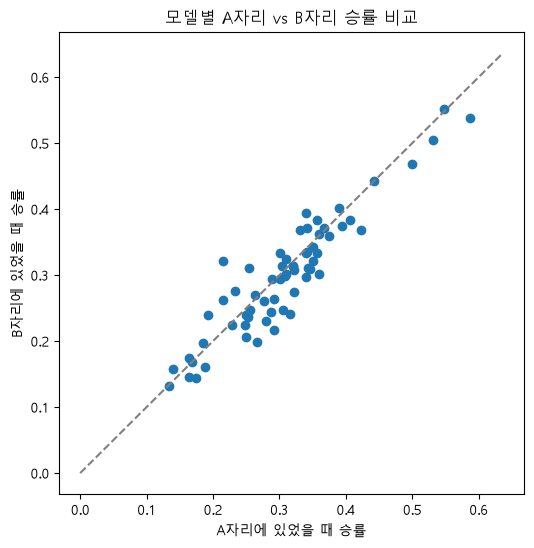

In [71]:
import matplotlib.pyplot as plt


plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False    

# 모델별로 A자리 승률과 B자리 승률의 차이를 계산
# (양수 >> 그 모델은 A자리에 있을 때 더 잘 이김 / 음수 >> B자리에 있을 때 더 잘 이김)
position_compare["diff"] = position_compare["win_rate_as_A"] - position_compare["win_rate_as_B"]

# 64개 모델 전체를 놓고, 평균적으로 어느 자리가 유리한지 확인
print("전체 모델 평균 차이 (A자리 - B자리):", position_compare["diff"].mean())
print("A자리가 더 유리했던 모델 수:", (position_compare["diff"] > 0).sum())
print("B자리가 더 유리했던 모델 수:", (position_compare["diff"] < 0).sum())

# 산점도: x축=A자리 승률, y축=B자리 승률
# 점이 점선 위에 있으면 위치 효과가 거의 없다
# (A자리 승률 = B자리 승률이라는 의미)
plt.figure(figsize=(6, 6))
plt.scatter(position_compare["win_rate_as_A"], position_compare["win_rate_as_B"])

max_val = position_compare[["win_rate_as_A", "win_rate_as_B"]].values.max() + 0.05
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray")  # 기준선(y=x)

plt.xlabel("A자리에 있었을 때 승률")
plt.ylabel("B자리에 있었을 때 승률")
plt.title("모델별 A자리 vs B자리 승률 비교")
plt.show()

**1번 결과**

- model_a/model_b 자리에 등장한 64개 모델이 모두 양쪽 자리에 다 나타남
   → 모델이 특정 위치에 고정 배정되지 않고, 배틀마다 무작위로 배정된다! 

- 64개 모델 전체의 A자리 승률과 B자리 승률을 비교:
  평균 차이는0.0091로 매우 작음. A자리가 더 유리했던 모델은 42개, B자리가
  더 유리했던 모델은 22개로 A쪽에 조금 더 몰려있지만, 평균 차이 자체가
  거의 0에 가까워 뚜렷한 위치 편향이 있다고 보기는 어려움

- 산점도에서도 점들이 대각선(y=x) 주변에 고르게 분포함 
   → 위치 효과가 강하지 않다는 결론 

→ 결론: 이 데이터에서 위치(A/B) 자체가 승패에 미치는 영향은 크지 않다.

**2. Verbosity bias(길이 편향):  응답 길이와 승패 관계 파악**


→ response_a/response_b가 JSON 문자열로 저장돼 있어서 json.loads()로
파싱해 응답 길이를 숫자 컬럼으로 만든다.

tie를 제외한 행에서 "이긴 쪽 응답 길이"와 "진 쪽 응답 길이"를
따로 모아, 두 그룹의 길이 분포를 박스플롯으로 비교해 경향을 파악한다.

In [72]:
import json

# response_a, response_b는 실제로는 여러 턴의 응답이 담긴 리스트인데,
# CSV에 저장되면서 JSON 문자열 형태로 저장돼 있음
# ('["안녕하세요"]' 같은 텍스트) -> json.loads()로 실제 리스트로 되돌림
def get_total_length(json_str):
    turns = json.loads(json_str)  # 문자열 -> 실제 파이썬 리스트로 변환
    # 응답이 없어서 null(None)로 저장된 턴이 있을 수 있어서,
    # None이면 길이 0으로 처리 (에러 방지)
    return sum(len(t) if t is not None else 0 for t in turns)

# test_df는 건드리지 않고, train_df에만 파생 컬럼 추가
train_df["response_a_len"] = train_df["response_a"].apply(get_total_length)
train_df["response_b_len"] = train_df["response_b"].apply(get_total_length)


print(train_df[["response_a_len", "response_b_len"]].describe())

       response_a_len  response_b_len
count    45981.000000    45981.000000
mean      1333.239751     1337.231661
std       1466.818011     1488.497263
min          0.000000        0.000000
25%        392.000000      398.000000
50%       1038.000000     1047.000000
75%       1813.000000     1818.000000
max      53265.000000    52371.000000


In [73]:
# tie는 누가 이겼는지 비교 대상이 없으므로 분석에서 제외
non_tie = train_df[train_df["winner"] != "tie"].copy()

import numpy as np

# winner가 "model_a"면 -> 이긴 쪽 길이는 response_a_len, 진 쪽은 response_b_len
# winner가 "model_b"면 -> 이긴 쪽 길이는 response_b_len, 진 쪽은 response_a_len
non_tie["winner_len"] = np.where(
    non_tie["winner"] == "model_a",
    non_tie["response_a_len"],
    non_tie["response_b_len"],
)
non_tie["loser_len"] = np.where(
    non_tie["winner"] == "model_a",
    non_tie["response_b_len"],
    non_tie["response_a_len"],
)

print(non_tie[["winner_len", "loser_len"]].describe())

         winner_len     loser_len
count  31757.000000  31757.000000
mean    1513.965834   1257.470699
std     1600.552979   1398.183311
min        0.000000      0.000000
25%      516.000000    374.000000
50%     1246.000000    953.000000
75%     2016.000000   1699.000000
max    53265.000000  28636.000000


이긴 쪽 평균 길이: 1513.965834304248
진 쪽 평균 길이: 1257.4706993733664
이긴 쪽 중앙값: 1246.0
진 쪽 중앙값: 953.0


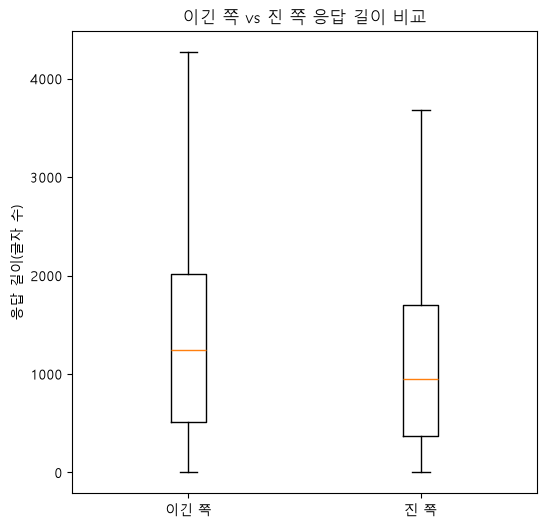

In [74]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 평균/중앙값
print("이긴 쪽 평균 길이:", non_tie["winner_len"].mean())
print("진 쪽 평균 길이:", non_tie["loser_len"].mean())
print("이긴 쪽 중앙값:", non_tie["winner_len"].median())
print("진 쪽 중앙값:", non_tie["loser_len"].median())

data_to_plot = [non_tie["winner_len"], non_tie["loser_len"]]

plt.figure(figsize=(6, 6))
plt.boxplot(data_to_plot, tick_labels=["이긴 쪽", "진 쪽"], showfliers=False)

plt.ylabel("응답 길이(글자 수)")
plt.title("이긴 쪽 vs 진 쪽 응답 길이 비교")
plt.show()

**2번 결과**

- 이긴 쪽 평균 응답 길이: 1513.97자 / 진 쪽 평균 응답 길이: 1257.47자
  (이긴 쪽이 약 256자, 20% 더 김)

- 이긴 쪽 중앙값: 1246자 / 진 쪽 중앙값: 953자 (약 30% 더 김)

- 박스플롯에서도 이긴 쪽 박스 전체(25%~75% 구간)가 진 쪽보다 위쪽에 위치함 
    → 평균만이 아니라 분포 전반에서 일관되게 이긴 쪽이 더 길다.

→ 결론: 이긴 쪽 응답이 진 쪽보다 전반적으로 더 긴 경향이 뚜렷하게
나타난다. 

**3. Turn count:  대화 길이와 승패 관계 파악**

대화가 길어질수록(주고받은 턴 수가
많을수록) 승패에 어떤 경향이 나타나는지 파악한다.

→ 먼저 한 행 안에서 prompt/response_a/response_b의 턴 수가 서로 같은지
검증한다 (이 데이터는 하나의 대화를 두 모델이 동시에 보고 각 턴마다 답하는
구조라서, 이론상 세 컬럼의 턴 수가 같아야 함). 
문제없음이 확인되면
turn_count 컬럼을 만들고, 무승부를 제외한 행에서 winner별로 턴 수 분포를
비교해 경향을 파악한다.

In [75]:
import json

# prompt, response_a, response_b 각각의 턴 수(리스트 길이)를 계산
def get_turn_count(json_str):
    return len(json.loads(json_str))

prompt_turns = train_df["prompt"].apply(get_turn_count)
a_turns = train_df["response_a"].apply(get_turn_count)
b_turns = train_df["response_b"].apply(get_turn_count)

# 세 컬럼의 턴 수가 전부 같은 행이 전체 중 몇 개인지 확인
same_count = ((prompt_turns == a_turns) & (a_turns == b_turns)).sum()
print(f"전체 {len(train_df)}행 중 세 턴 수가 모두 같은 행: {same_count}개")

전체 45981행 중 세 턴 수가 모두 같은 행: 45981개


           count      mean       std  min  25%  50%  75%   max
winner                                                        
model_a  16034.0  1.254210  0.934045  1.0  1.0  1.0  1.0  35.0
model_b  15723.0  1.258220  0.941409  1.0  1.0  1.0  1.0  36.0
tie      14224.0  1.222511  0.878419  1.0  1.0  1.0  1.0  32.0


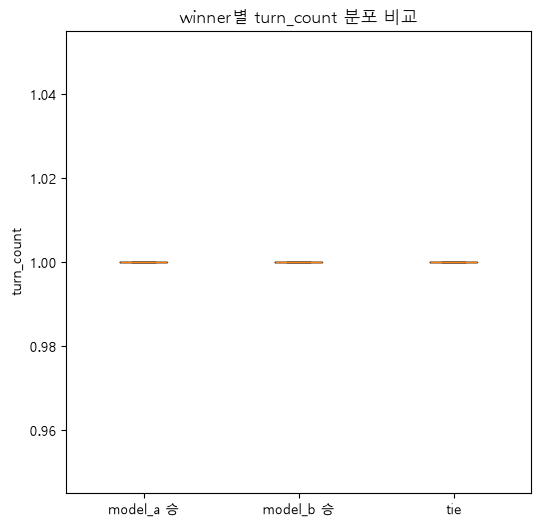

In [76]:
# 아까 검증할 때 이미 계산해둔 prompt_turns를 그대로 turn_count로 사용
train_df["turn_count"] = prompt_turns

# winner(model_a 승 / model_b 승 / 무승부)별로 턴 수 통계 확인
print(train_df.groupby("winner")["turn_count"].describe())

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# winner 값별로 turn_count를 따로 묶어서 박스플롯에 넣을 리스트를 만듦
data_to_plot = [
    train_df.loc[train_df["winner"] == "model_a", "turn_count"],
    train_df.loc[train_df["winner"] == "model_b", "turn_count"],
    train_df.loc[train_df["winner"] == "tie", "turn_count"],
]

plt.figure(figsize=(6, 6))
plt.boxplot(data_to_plot, tick_labels=["model_a 승", "model_b 승", "tie"], showfliers=False)
plt.ylabel("turn_count")
plt.title("winner별 turn_count 분포 비교")
plt.show()

In [77]:
print(train_df["turn_count"].value_counts().sort_index())

turn_count
1     39945
2      3710
3      1202
4       498
5       261
6       136
7        76
8        45
9        38
10       22
11       13
12       12
13        3
14        2
15        1
16        2
17        2
18        1
19        4
20        2
21        1
22        1
29        1
32        1
35        1
36        1
Name: count, dtype: int64


**3번 결과**

- 전체 45,981행 중 39,945행(약 86.9%)이 1턴짜리 대화 → 대부분의 배틀이
  단일 턴으로 끝남

- winner별 turn_count 평균: model_a 승 1.254 / model_b 승 1.258 / tie
  1.223 → 그룹 간 차이는 0.03~0.04 수준으로 매우 작음

- 박스플롯에서도 세 그룹의 중앙값/사분위수가 거의 겹쳐서 시각적 차이가
  뚜렷하지 않음

→ 결론: 턴 수는 대부분 1에 몰려있어 변별력이 크지 않았고, winner 그룹
간 차이도 작아서 턴 수가 길수록 승패에 영향을 준다는 뚜렷한 경향은
관찰되지 않았다.  

### 변수별 특징 정리


| 변수 | 설명 | 특징 |
|---|---|---|
| id | 각 배틀의 고유 식별자 | 분석에 사용되지 않는 단순 식별자 |
| model_a / model_b | 각 배틀에서 두 모델이 배정된 위치 | 배틀마다 무작위로 배정됨. 위치 자체가 승패에 주는 영향은 작음 |
| prompt / response_a / response_b | 사용자 질문 및 두 모델의 응답(JSON 형태의 다중 턴 텍스트) | 결측치 x, 원본은 텍스트라 길이/턴 수 등 숫자형 파생 변수로 변환해 활용 |
| response_a_len / response_b_len (파생) | 각 응답의 전체 글자 수 | 이긴 쪽 응답이 진 쪽보다 평균 20% 더 김 → winner와 가장 뚜렷한 관계를 보임 |
| turn_count (파생) | 배틀 내 오간 대화 턴 수 | 전체의 86.9%가 1턴으로 값이 거의 몰려 있어 변동성이 작다. winner 그룹 간 평균 차이도 0.03~0.04로 작음 |
| winner_model_a / winner_model_b / winner_tie | 승패를 나타내는 0/1 컬럼 3개 | winner 컬럼 하나로 통합, 결측치 x |
| winner (target, 파생) | model_a 승 / model_b 승 / 무승부를 합친 target 변수 | 34.91% / 34.19% / 30.90%로 비교적 균형 잡힌 분포 |

=> 원본 변수 중 위치(model_a/model_b)나 텍스트 자체는 결측치 x.
   하지만 그 자체로는 승패를 설명하지 못했고, 텍스트에서 파생시킨 응답 길이 변수가 승패와 가장 뚜렷한 관계를 보임.
   
   이후 모델링 단계에서 원본 텍스트보다 응답 길이 같은 파생 변수를 우선적으로 고려해볼 예정.. 

-------------------------------------------------------------------------------------------------------------

## Week2

## TASK 1: 데이터 전처리

**결측치 처리**

1주차 TASK2에서 원본 데이터 전체 컬럼의 결측치 비율이 0%임을 확인함.
새로 만든 파생 변수(response_a_len, response_b_len, turn_count)도
describe() 결과 count가 45,981로 전체 행 수와 일치하기 때문에 이 데이터에는 결측치가 없다!

In [78]:
# IQR(사분위 범위) 방식으로 이상치 경계를 계산함.
# Q1, Q3를 구하고, IQR의 1.5배를 벗어나면 이상치로 보는 방식.
def get_iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

a_lower, a_upper = get_iqr_bounds(train_df["response_a_len"])
b_lower, b_upper = get_iqr_bounds(train_df["response_b_len"])

print(f"response_a_len 정상 범위: {a_lower} ~ {a_upper}")
print(f"response_b_len 정상 범위: {b_lower} ~ {b_upper}")

# 이 범위를 벗어나는 행이 몇 개인지 확인한다.
a_outliers = ((train_df["response_a_len"] < a_lower) | (train_df["response_a_len"] > a_upper)).sum()
b_outliers = ((train_df["response_b_len"] < b_lower) | (train_df["response_b_len"] > b_upper)).sum()

print(f"response_a_len 이상치 개수: {a_outliers} ({a_outliers/len(train_df)*100:.2f}%)")
print(f"response_b_len 이상치 개수: {b_outliers} ({b_outliers/len(train_df)*100:.2f}%)")

# 이상치 처리 방법으로 삭제 대신 클리핑을 선택함
# 이상치 비율이 3.90%, 3.85%(약 1800개)로 적지 않음. 삭제시 데이터 손실이 크다.
#  >> 이 값들은 입력 오류 x 실제로 긴 응답이므로 -> 값을 없애기보다 극단적인 영향력만 제한하자!
#  >> 하한선 -1739.5, -1732.0은 음수라 실제 데이터(최소 0자)에는 해당하는 값이 없어서 상한선만 클리핑
train_df["response_a_len"] = train_df["response_a_len"].clip(upper=a_upper)
train_df["response_b_len"] = train_df["response_b_len"].clip(upper=b_upper)

print(train_df[["response_a_len", "response_b_len"]].describe())

response_a_len 정상 범위: -1739.5 ~ 3944.5
response_b_len 정상 범위: -1732.0 ~ 3948.0
response_a_len 이상치 개수: 1792 (3.90%)
response_b_len 이상치 개수: 1771 (3.85%)
       response_a_len  response_b_len
count    45981.000000    45981.000000
mean      1243.854527     1246.957983
std       1031.589636     1027.959833
min          0.000000        0.000000
25%        392.000000      398.000000
50%       1038.000000     1047.000000
75%       1813.000000     1818.000000
max       3944.500000     3948.000000


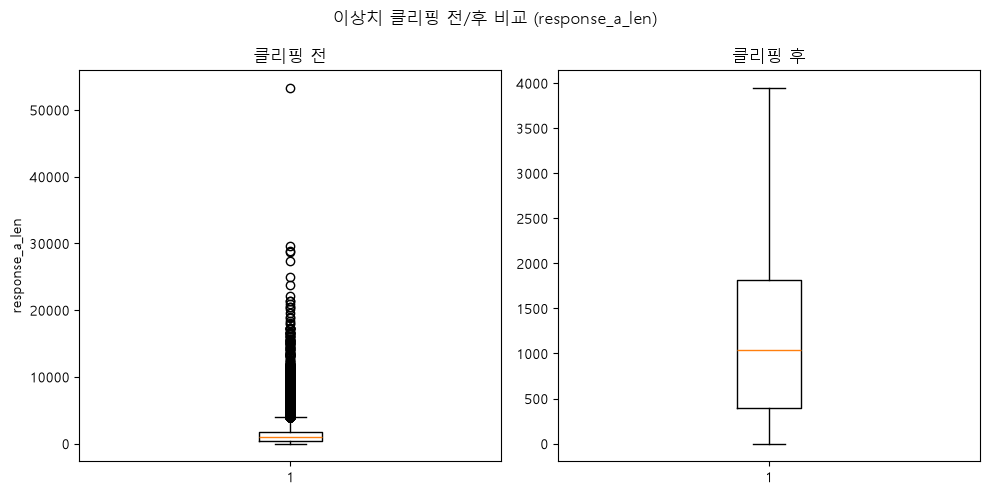

In [79]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 클리핑 전/후 비교 
# train_df["response_a_len"]은 이전 셀에서 .clip()으로 같은 컬럼에 덮어씀 = 클리핑 후의 값
# 원본 텍스트에서 get_total_length 함수로 클리핑 전 길이를 다시 계산 = 클리핑 전의 값
response_a_len_before = train_df["response_a"].apply(get_total_length)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].boxplot(response_a_len_before)
axes[0].set_title("클리핑 전")
axes[0].set_ylabel("response_a_len")

axes[1].boxplot(train_df["response_a_len"])
axes[1].set_title("클리핑 후")

plt.suptitle("이상치 클리핑 전/후 비교 (response_a_len)")
plt.tight_layout()
plt.show()

**이상치 처리**

response_a_len/response_b_len에 IQR 방식(Q1-1.5×IQR ~ Q3+1.5×IQR)을 적용해 경계를 계산함.

-> 하한선은 음수로 나와 실제 데이터에 해당 x. 상한선을 넘는 행은 각각 3.90%(1792개), 3.85%(1771개)임(실제로 길게 입력된 응답).

-> 상한선으로 클리핑

-> (클리핑 후) 
   
    평균: 1333→1244자, 1337→1247자 (낮아짐)

    표준편차: 1467→1032, 1488→1028 (극단값 영향 완화)

    중앙값: 1038, 1047자 동일 (분포 중심 보존)


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["response_a_len", "response_b_len", "turn_count"]
categorical_features = ["model_a", "model_b"]

# [ColumnTransformer] 숫자형 컬럼: StandardScaler, 범주형 컬럼: OneHotEncoder 
# 각각 다르게 적용해서 하나로 묶어준다. 
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),

    # handle_unknown="ignore": 에러 없이 처리 (나중에 검증/테스트 데이터에 못 봤던 모델 이름이 나올 경우만 해당)
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

 
X_train_processed = preprocessor.fit_transform(train_df)

print(X_train_processed.shape)

(45981, 131)


**인코딩 / 스케일링**

`model_a`/`model_b`(범주형)는 `OneHotEncoder`로, 
`response_a_len`/ `response_b_len`/`turn_count`(숫자형)는 `StandardScaler`로 변환.

`ColumnTransformer`로 두 변환을 하나로 묶음!

train_df에만 fit_transform을 적용 -> 데이터 누수 방지,

숫자형 3개 + model_a 64종 + model_b 64종이 원-핫 인코딩되어 총 131개 컬럼으로 변환된 것 확인. 

test_df에는 이후 최종 평가 단계에서 동일한 ColumnTransformer 구조로
train 데이터에 fit한 preprocessor를 이용해 transform만 적용할 예정이다.
(재학습 x).

## TASK 2: 피쳐 엔지니어링

1주차 EDA 결과를 바탕으로, 새로운 파생변수 2개를 만듦.

**1. length_diff = response_a_len - response_b_len**

1주차에서 "이긴 쪽 응답이 더 길다"는 경향(verbosity bias) 확인.
-> 이걸 모델이 바로 활용할 수 있는 숫자 하나로 압축한다. 

+) winner_len - loser_len 차이가 통계적으로 유의미한지 paired t-test로 추가 검증 진행. 
    (같은 배틀에서 나온 두 값이므로 독립표본이 아닌 대응표본 검정을 사용)


In [81]:
from scipy import stats

# 파생변수 1: 두 응답 길이의 차이 (양수면 A가 더 길고, 음수면 B가 더 길다.)
train_df["length_diff"] = train_df["response_a_len"] - train_df["response_b_len"]

# 무승부 제외하고, "이긴 쪽 길이" vs "진 쪽 길이"로 재정리 
non_tie = train_df[train_df["winner"] != "tie"].copy()
non_tie["winner_len"] = np.where(non_tie["winner"] == "model_a", non_tie["response_a_len"], non_tie["response_b_len"])
non_tie["loser_len"] = np.where(non_tie["winner"] == "model_a", non_tie["response_b_len"], non_tie["response_a_len"])

# 대응표본 t-test: 같은 행에서 나온 두 값이라서 paired t-test 사용함.
t_stat, p_value = stats.ttest_rel(non_tie["winner_len"], non_tie["loser_len"])
print(f"t-통계량: {t_stat:.4f}, p-value: {p_value}")

t-통계량: 49.2571, p-value: 0.0


**length_diff 통계 검증 결과**

대응표본 t-test 결과 t = 49.26, p < 0.001로(p-value가 0에 극도로 가까움), 
이긴 쪽 응답이 진 쪽보다 긴 경향은 통계적으로 유의미한 차이다!
 

**2. is_same_model = (model_a == model_b)**

같은 모델끼리 붙은 배틀인지 여부를 나타내는 변수. 
(why?-같은 모델이 스스로와 경쟁하는 경우, 실력 차이가 없으므로 tie 비율이 더 높을 것이다!)


In [82]:
# 파생변수 2: 같은 모델끼리 붙은 배틀인지.. (1: 동일 모델 / 0: 다른 모델)
train_df["is_same_model"] = (train_df["model_a"] == train_df["model_b"]).astype(int)

print(train_df["is_same_model"].value_counts())

# # 그룹(같은 모델 vs 다른 모델)별로 winner 비율을 비교 -> 같은 모델끼리는 tie 비율이 더 높은지 확인
print(train_df.groupby("is_same_model")["winner"].value_counts(normalize=True))

is_same_model
0    45981
Name: count, dtype: int64
is_same_model  winner 
0              model_a    0.348709
               model_b    0.341946
               tie        0.309345
Name: proportion, dtype: float64


In [83]:
# 실제로 응답 길이가 0인 행이 존재하는지 확인 

print((train_df["response_a_len"] == 0).sum(), (train_df["response_b_len"] == 0).sum())

26 25


In [84]:
# is_same_model 삭제: 동일 모델 배틀이 데이터에 하나도 없어(전부 0) 가설 비교 자체가 불가능한 실패한 변수 
# (errors="ignore": 이미 삭제된 상태에서 셀을 다시 실행해도 에러 안 나게)
train_df = train_df.drop(columns=["is_same_model"], errors="ignore")

import numpy as np

# 파생변수 2-2: 로그 비율 = log(a_len+1) - log(b_len+1) = log((a_len+1)/(b_len+1))

# 비율은 0~1 구간은 좁고 1~무한대 구간은 넓어서 한쪽으로 치우친 분포가 되는데,
# 이때, 로그를 취하면 0을 기준으로 좌우 대칭에 가까운 분포가 되기 때문에 로그를 사용함.

# response_a_len == 0인 행 26개, response_b_len == 0인 행 25개
# +1 없이 log(0)을 계산하면 -inf가 나와 length_ratio 값이 깨지므로, 이를 방지하기 위해 보정
train_df["length_ratio"] = np.log(train_df["response_a_len"] + 1) - np.log(train_df["response_b_len"] + 1)

print(train_df["length_ratio"].describe())

count    45981.000000
mean        -0.007270
std          1.055872
min         -8.048149
25%         -0.455476
50%         -0.000887
75%          0.447577
max          8.247744
Name: length_ratio, dtype: float64


**TASK2 결과 정리**

1. **length_diff** (response_a_len - response_b_len)

   대응표본 t-test 결과 t=49.26, p<0.001로, 이긴 쪽이 더 긴 경향은
   통계적으로 유의미했다.

2. **length_ratio** (log(response_a_len+1) - log(response_b_len+1))

   1) "같은 모델끼리 붙었는지(is_same_model)"를 두 번째 변수로 시도함
       -> 이 데이터에서 model_a/model_b가 같은 모델로 매칭된 적이 x(변별력이 없는 변수) 
       
   2) 두 응답 길이의 비율을 사용
      - 단순 비율은 분모가 0에 가까울 때 값이 극단적으로 커지는 문제(최대 3818)가 있어 
         로그 비율로 변환함. 
         -> 평균 -0.007, 표준편차 1.06의 안정적인 분포로 바뀜.
            0을 기준으로 양수면 A가 더 김, 음수면 B가 더 길다는 것을 안정적인 스케일로 나타낸다.

## TASK 3: 베이스라인 모델

1. train_df 안에서 train/validation으로 분리

2. 전처리(ColumnTransformer) + LogisticRegression을 하나의 Pipeline으로 묶어서 학습
   - 전처리 파라미터(평균/표준편차, 카테고리 목록 등)는 train에서만 fit하고,
     validation에는 그 fit된 파라미터로 transform만 적용
   - 전처리 자체가 validation의 정보를 미리 학습해버리는 것 방지

3. validation에서 여러 각도로 평가:
   - Log Loss 
   - Accuracy
   - Confusion Matrix 

4. 비교 기준선(DummyClassifier)과 비교  

5. LogisticRegression의 계수(coefficient) 확인 
   - EDA에서 찾았던 length_diff가 실제로 모델에서도 중요하게 반영되는지를 검증

In [85]:
from sklearn.model_selection import train_test_split

# train_df를 다시 한 번 train_sub(학습용) / val_df(검증용)로 나눔
# 1주차 TASK3와 같은 방식(8:2, random_state=42)을 그대로 적용함

train_sub, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
)

print(train_sub.shape, val_df.shape)

(36784, 15) (9197, 15)


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# length_diff/length_ratio만 사용
numeric_features = ["turn_count", "length_diff", "length_ratio"]
categorical_features = ["model_a", "model_b"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

# 전처리기 + 모델을 하나의 Pipeline으로 묶음.
# baseline_model.fit(X_train_sub, y_train_sub)를 하면 전처리기도 X_train_sub(train_sub에서 추출)에만 fit되고
# 모델도 그 결과로 학습됨 -> 데이터 누수 걱정 없이 한 번에 처리된다!
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),  # max_iter를 늘려서 수렴 경고 방지
])

X_train_sub = train_sub[numeric_features + categorical_features]
y_train_sub = train_sub["winner"]

X_val = val_df[numeric_features + categorical_features]
y_val = val_df["winner"]

# train_sub로만 학습 
baseline_model.fit(X_train_sub, y_train_sub)

print("학습 완료")

학습 완료


In [87]:
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix

# Log Loss는 확률이 필요해서 predict_proba 사용
# Accuracy/Confusion Matrix는 최종 예측 클래스가 필요해서 predict 사용
y_val_proba = baseline_model.predict_proba(X_val)
y_val_pred = baseline_model.predict(X_val)

# labels=baseline_model.classes_로 확률 컬럼 순서 명시 
loss = log_loss(y_val, y_val_proba, labels=baseline_model.classes_)
acc = accuracy_score(y_val, y_val_pred)

print(f"Log Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

print(f"\n클래스 순서: {list(baseline_model.classes_)}")
print("Confusion Matrix (행: 실제값, 열: 예측값)")
print(confusion_matrix(y_val, y_val_pred, labels=baseline_model.classes_))

Log Loss: 1.0298
Accuracy: 0.4643

클래스 순서: ['model_a', 'model_b', 'tie']
Confusion Matrix (행: 실제값, 열: 예측값)
[[2010  873  292]
 [ 954 1937  281]
 [1317 1210  323]]


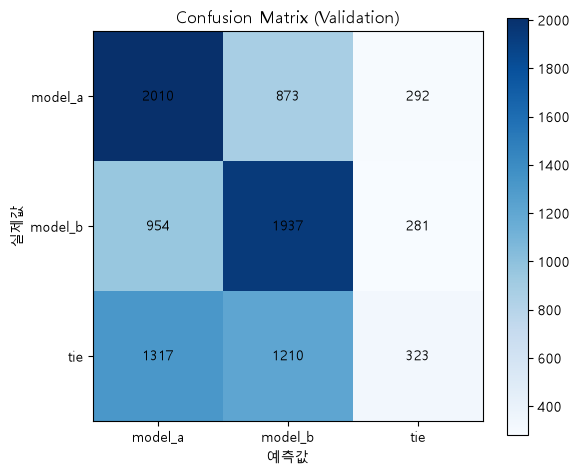

In [88]:
cm = confusion_matrix(y_val, y_val_pred, labels=baseline_model.classes_)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

# 각 칸 안에 실제 숫자를 텍스트로 표시함 
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

ax.set_xticks(range(len(baseline_model.classes_)))
ax.set_yticks(range(len(baseline_model.classes_)))
ax.set_xticklabels(baseline_model.classes_)
ax.set_yticklabels(baseline_model.classes_)
ax.set_xlabel("예측값")
ax.set_ylabel("실제값")
ax.set_title("Confusion Matrix (Validation)")

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [89]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss, accuracy_score

# strategy="prior": 클래스 비율만 가지고 확률을 찍는 기준선
# (사실상 아무 정보도 사용하지 x )
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train_sub, y_train_sub)

dummy_proba = dummy.predict_proba(X_val)
dummy_pred = dummy.predict(X_val)

dummy_loss = log_loss(y_val, dummy_proba, labels=dummy.classes_)
dummy_acc = accuracy_score(y_val, dummy_pred)

print(f"[더미 기준선]        Log Loss: {dummy_loss:.4f}, Accuracy: {dummy_acc:.4f}")
print(f"[LogisticRegression] Log Loss: {loss:.4f}, Accuracy: {acc:.4f}")

[더미 기준선]        Log Loss: 1.0974, Accuracy: 0.3452
[LogisticRegression] Log Loss: 1.0298, Accuracy: 0.4643


In [90]:
import pandas as pd

# ColumnTransformer가 변환한 컬럼들의 실제 이름을 가져옴
# (숫자형은 "num__컬럼명", 범주형은 "cat__컬럼명_값" 형태)
feature_names = baseline_model.named_steps["preprocessor"].get_feature_names_out()

# Pipeline 안의 LogisticRegression만 꺼내서 학습된 계수(coef_)를 가져옴
# winner가 3개 클래스 -> coef_는 (3, 전체 피처 수) 모양으로 나옴
coefs = baseline_model.named_steps["classifier"].coef_

coef_df = pd.DataFrame(coefs, columns=feature_names, index=baseline_model.classes_)

# coef_df에는 범주형(model_a/model_b, 총 100개 이상) 열까지 다 섞여 있음
# 그중 직접 만든 숫자형 피처 3개(turn_count, length_diff, length_ratio)의 계수만 이름으로 골라서 확인!
numeric_coef_names = [f"num__{f}" for f in numeric_features]
print(coef_df[numeric_coef_names])

         num__turn_count  num__length_diff  num__length_ratio
model_a         0.013602          0.217208           0.060441
model_b         0.010173         -0.224695          -0.059892
tie            -0.023775          0.007488          -0.000549


train_df를 다시 train_sub(80%)/val_df(20%)로 분리하고, 전처리(ColumnTransformer: StandardScaler+OneHotEncoder)와
LogisticRegression을 하나의 Pipeline으로 묶어 train_sub에만 fit했다.

**성능 (validation 기준)**
| 지표 | 더미 기준선(prior) | LogisticRegression |
|---|---|---|
| Log Loss | 1.0974 | **1.0298** |
| Accuracy | 34.52% | **46.43%** |

더미 기준선(클래스 비율만 찍는 것) 대비 Log Loss는 낮아지고 Accuracy는 높아짐
->  지금까지 만든 피처들이 실제로 예측에 도움이 되었다!

**Confusion Matrix로 본 한계**
클래스별 재현율은 model_a 63.31%, model_b 61.07%인 반면 tie는 11.33%.
->  모델은 "둘 중 누가 이기는지"는 어느 정도 구분하지만 "무승부"는 거의 예측하지 못한다.
    (현재 피처들(길이, 모델 정체성)이 "어느 쪽이 우세한가"는 반영하지만 "둘이 얼마나 비슷한가"는 담아내지 x)

**계수로 본 EDA 검증**
length_diff 방향이 1주차 verbosity bias와 일치 → EDA 발견이 모델에서도 재확인됨

**베이스라인 점수**
Log Loss = 1.0298

--------------------------------------------------------------------------------------------------------------------

## Week3

## 파생변수 추가 가설 검증

2주차 베이스라인의 한계(tie recall만 유독 낮음)보완을 위해
새 파생변수를 추가 작업.

**가설: 무승부는 두 응답의 길이 차이가 작을 때 더 많이 발생할 것이다**

지금까지 쓴 length_diff/length_ratio는 "누가 더 긴지 방향"만 담고 있어(양수=A가 더 김, 음수=B가 더 김),
무승부처럼 "얼마나 비슷한지"가 중요한 경우를 구분하지 못했을 수 있음.
-> 이 가설이 실제 데이터로 뒷받침되는지 winner 그룹별 비교로 확인하고,
   방향을 없애고 크기(절댓값)만 남긴 abs_length_diff를 추가 
   

               mean  median         std
winner                                 
model_a  604.783678   422.0  595.885698
model_b  610.534154   431.0  598.436223
tie      456.704654   287.0  504.515099


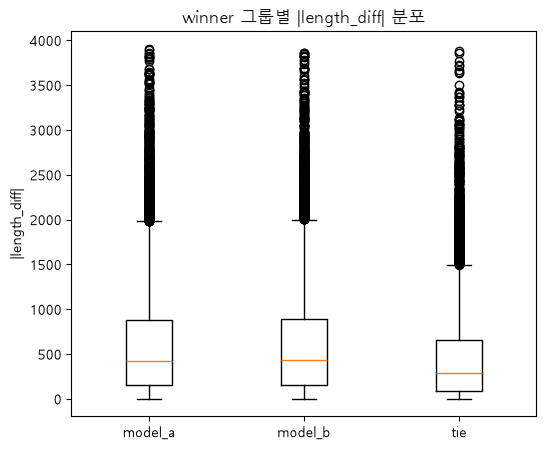

In [91]:
import matplotlib.pyplot as plt

# 가설 검증: winner 그룹(model_a/model_b/tie)별로 |length_diff|의 평균/중앙값/표준편차 비교
train_df["abs_length_diff"] = train_df["length_diff"].abs()

print(train_df.groupby("winner")["abs_length_diff"].agg(["mean", "median", "std"]))

# 그룹별 분포를 박스플롯으로도 시각화
groups = ["model_a", "model_b", "tie"]
data_by_group = [train_df[train_df["winner"] == g]["abs_length_diff"] for g in groups]

plt.figure(figsize=(6, 5))
plt.boxplot(data_by_group)
plt.xticks([1, 2, 3], groups)  
plt.ylabel("|length_diff|")
plt.title("winner 그룹별 |length_diff| 분포")
plt.show()

In [92]:
from scipy import stats

# tie 그룹 vs non-tie(model_a+model_b) 그룹의 |length_diff| 비교
# 서로 다른 행들끼리 비교하는 거라 대응표본이 아닌 독립표본 t-test 사용
tie_abs_diff = train_df[train_df["winner"] == "tie"]["abs_length_diff"]
non_tie_abs_diff = train_df[train_df["winner"] != "tie"]["abs_length_diff"]

t_stat, p_value = stats.ttest_ind(tie_abs_diff, non_tie_abs_diff)
print(f"t-통계량: {t_stat:.4f}, p-value: {p_value}")

t-통계량: -26.2393, p-value: 1.2236281945459555e-150


**abs_length_diff 가설 검증 결과**

winner 그룹별 |length_diff| 평균: model_a 604.78, model_b 610.53, tie 456.70

-> tie 그룹이 다른 두 그룹보다 약 25% 작게 나타남(중앙값 기준 약 33% 작음).

독립표본 t-test 결과 t=-26.24, p<0.001로,
"두 응답 길이가 비슷할수록 무승부가 나올 가능성이 높다"는 가설이 통계적으로 유의미함.

-> abs_length_diff를 새 파생변수로 추가!

In [93]:
train_df["abs_length_ratio"] = train_df["length_ratio"].abs()

print(train_df.groupby("winner")["abs_length_ratio"].agg(["mean", "median", "std"]))

tie_abs_ratio = train_df[train_df["winner"] == "tie"]["abs_length_ratio"]
non_tie_abs_ratio = train_df[train_df["winner"] != "tie"]["abs_length_ratio"]

t_stat2, p_value2 = stats.ttest_ind(tie_abs_ratio, non_tie_abs_ratio)
print(f"t-통계량: {t_stat2:.4f}, p-value: {p_value2}")

             mean    median       std
winner                               
model_a  0.736342  0.479894  0.802489
model_b  0.746890  0.486720  0.803601
tie      0.629252  0.379251  0.735272
t-통계량: -14.2222, p-value: 8.342472207847514e-46


**abs_length_ratio 가설 검증 결과**

winner 그룹별 |length_ratio| 평균: model_a 0.736, model_b 0.747, tie 0.629

-> tie 그룹이 다른 두 그룹보다 약 15% 작게 나타남(중앙값 기준 약 21% 작음).

독립표본 t-test 결과 t=-14.22, p<0.001로, 
"두 응답이 비슷할수록 무승부 가능성이 높다"는 가설이 통계적으로 유의미함.

+) t-통계량 크기가 abs_length_diff(-26.24)보다 작아, tie 구분 신호는
abs_length_diff 쪽이 조금 더 뚜렷함.

-> abs_length_ratio도 새 파생변수로 추가!

**베이스라인 재학습 (abs_length_diff, abs_length_ratio 추가)**

가설 검증 -> abs_length_diff/abs_length_ratio 둘 다 tie 여부와 통계적으로 유의미함을 확인.

-> numeric_features에 두 변수를 추가, 베이스라인부터 다시 학습해 공통 기준을 맞추기. train_sub/val_df에 들어가는 행 자체는 그대로 유지함. (사용하는 피처 컬럼만 3개 -> 5개로 늘어남)

In [94]:
# numeric_features 업데이트: 기존 3개(turn_count, length_diff, length_ratio) + abs_length_diff, abs_length_ratio 추가
numeric_features = ["turn_count", "length_diff", "length_ratio", "abs_length_diff", "abs_length_ratio"]
categorical_features = ["model_a", "model_b"]

# train_sub/val_df는 abs 피처를 만들기 전에 이미 나눠짐
# -> 각각에 대해 abs 컬럼 직접 생성
train_sub["abs_length_diff"] = train_sub["length_diff"].abs()
train_sub["abs_length_ratio"] = train_sub["length_ratio"].abs()

val_df["abs_length_diff"] = val_df["length_diff"].abs()
val_df["abs_length_ratio"] = val_df["length_ratio"].abs()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

# 베이스라인 재학습 (피처만 5개로 확장)
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

X_train_sub = train_sub[numeric_features + categorical_features]
y_train_sub = train_sub["winner"]

X_val = val_df[numeric_features + categorical_features]
y_val = val_df["winner"]

baseline_model.fit(X_train_sub, y_train_sub)

print("베이스라인 재학습 완료 (숫자형 피처 5개 반영)")

베이스라인 재학습 완료 (숫자형 피처 5개 반영)


In [95]:
y_val_proba = baseline_model.predict_proba(X_val)
y_val_pred = baseline_model.predict(X_val)

loss = log_loss(y_val, y_val_proba, labels=baseline_model.classes_)
acc = accuracy_score(y_val, y_val_pred)

print(f"Log Loss: {loss:.4f}")
print(f"Accuracy: {acc:.4f}")

print(f"\n클래스 순서: {list(baseline_model.classes_)}")
print("Confusion Matrix (행: 실제값, 열: 예측값)")
print(confusion_matrix(y_val, y_val_pred, labels=baseline_model.classes_))

Log Loss: 1.0237
Accuracy: 0.4731

클래스 순서: ['model_a', 'model_b', 'tie']
Confusion Matrix (행: 실제값, 열: 예측값)
[[1865  778  532]
 [ 847 1795  530]
 [1117 1042  691]]


**베이스라인 재학습 결과 (abs 피처 추가)**

| 지표 | 기존 베이스라인 | 재학습 베이스라인 |
|---|---|---|
| Log Loss | 1.0298 | **1.0237** |
| Accuracy | 46.43% | **47.31%** |
| tie 재현율 | 11.33% | **24.25%** |

abs_length_diff, abs_length_ratio 추가 후 Log Loss/Accuracy 개선,
tie 재현율 11.33% → 24.25%로 2배 이상 증가함.(model_a/model_b 재현율은 미세하게 떨어짐)

-> "두 응답 길이가 비슷할수록 무승부 가능성이 높다"는 가설 -> 실제 모델 성능 개선으로 이어짐.

## TASK 1: 모델 2(L1 규제 로지스틱 회귀)-선형 계열

**모델 선택 이유**

베이스라인: 기본 L2 규제 로지스틱 회귀를 사용함. 
L1 규제는 중요하지 않은 피처의 계수를 아예 0으로 만들 수 있다.
-> 이전에 확인한 "turn_count는 승패에 거의 영향 없음"이라는 결론이 L1에서도 재확인되는지 검증하기 위해 선택함.


**하이퍼파라미터 설정 이유**

- penalty="l1": 규제 방식을 L1으로 지정
- solver="saga": L1 규제와 다중분류를 동시에 지원하는 solver로 선택
- class_weight="balanced": tie처럼 재현율이 낮은 클래스에 모델이 더 신경 쓰도록 함
- max_iter=1000: 수렴 경고 방지 (saga가 수렴이 느리면 이후 더 늘릴 수 있음)

In [96]:
preprocessor2 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

# 모델 2: L1 규제 로지스틱 회귀 (multinomial + class_weight="balanced")
model2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=1000
    )),
])

model2.fit(X_train_sub, y_train_sub)

print("모델 2(L1 로지스틱) 학습 완료")

c:\Users\gjymo\OneDrive\바탕 화면\pilot_LLM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gjymo\OneDrive\바탕 화면\pilot_LLM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


모델 2(L1 로지스틱) 학습 완료


In [97]:
# 모델 2 평가 (베이스라인과 동일)
y_val_proba2 = model2.predict_proba(X_val)
y_val_pred2 = model2.predict(X_val)

loss2 = log_loss(y_val, y_val_proba2, labels=model2.classes_)
acc2 = accuracy_score(y_val, y_val_pred2)

print(f"Log Loss: {loss2:.4f}")
print(f"Accuracy: {acc2:.4f}")

print(f"\n클래스 순서: {list(model2.classes_)}")
print("Confusion Matrix (행: 실제값, 열: 예측값)")
print(confusion_matrix(y_val, y_val_pred2, labels=model2.classes_))

Log Loss: 1.0248
Accuracy: 0.4725

클래스 순서: ['model_a', 'model_b', 'tie']
Confusion Matrix (행: 실제값, 열: 예측값)
[[1664  669  842]
 [ 679 1659  834]
 [ 916  911 1023]]


In [98]:
# Model 2(L1)의 계수 확인: turn_count가 실제로 0에 가까워졌는지..
# (2주차 베이스라인에서 했던 coef_df 패턴과 동일한 방식)

feature_names2 = model2.named_steps["preprocessor"].get_feature_names_out()

coef_df2 = pd.DataFrame(
    model2.named_steps["classifier"].coef_,
    columns=feature_names2,
    index=model2.classes_
)

print("Model 2 (L1) 계수:")
print(coef_df2)

print("\nturn_count 계수만 따로 확인:")
print(coef_df2["num__turn_count"])

Model 2 (L1) 계수:
         num__turn_count  num__length_diff  num__length_ratio  \
model_a         0.003707          0.172212           0.070096   
model_b         0.000000         -0.199049          -0.061292   
tie            -0.033089          0.000000           0.000000   

         num__abs_length_diff  num__abs_length_ratio  \
model_a              0.009117               0.000000   
model_b              0.000000               0.000325   
tie                 -0.222738              -0.021726   

         cat__model_a_RWKV-4-Raven-14B  cat__model_a_alpaca-13b  \
model_a                      -0.418066                -0.407104   
model_b                       0.615021                 0.136905   
tie                           0.000000                 0.000000   

         cat__model_a_chatglm-6b  cat__model_a_chatglm2-6b  \
model_a                -1.086164                 -0.788481   
model_b                 0.565050                  0.487675   
tie                     0.000000          

In [99]:
# 각 클래스별로 계수가 0인 비율 확인 
for cls in coef_df2.index:
    total = len(coef_df2.columns)
    zero_count = (coef_df2.loc[cls] == 0).sum()
    print(f"{cls}: 전체 {total}개 특성 중 {zero_count}개가 정확히 0 ({zero_count/total*100:.1f}%)")

print("\n--- tie 클래스에서 0이 아닌 계수만 ---")
tie_coefs = coef_df2.loc["tie"]
print(tie_coefs[tie_coefs != 0])

model_a: 전체 133개 특성 중 22개가 정확히 0 (16.5%)
model_b: 전체 133개 특성 중 24개가 정확히 0 (18.0%)
tie: 전체 133개 특성 중 100개가 정확히 0 (75.2%)

--- tie 클래스에서 0이 아닌 계수만 ---
num__turn_count                               -0.033089
num__abs_length_diff                          -0.222738
num__abs_length_ratio                         -0.021726
cat__model_a_dolphin-2.2.1-mistral-7b          0.240368
cat__model_a_llama-2-70b-chat                  0.060802
cat__model_a_llama-2-7b-chat                   0.080568
cat__model_a_mistral-7b-instruct-v0.2         -0.072320
cat__model_a_mpt-30b-chat                      0.116286
cat__model_a_nous-hermes-2-mixtral-8x7b-dpo   -0.198969
cat__model_a_openchat-3.5-0106                -0.034484
cat__model_a_openhermes-2.5-mistral-7b         0.076324
cat__model_a_pplx-7b-online                   -0.154295
cat__model_a_qwen1.5-7b-chat                  -0.301898
cat__model_a_starling-lm-7b-alpha             -0.070144
cat__model_a_stripedhyena-nous-7b              0.096355
cat__model_

## 모델 2: L1 로지스틱 회귀  


| 지표 | 베이스라인 | 모델 2 (L1+balanced) |
|---|---|---|
| Log Loss | 1.0237 | 1.0248 |
| Accuracy | 47.31% | 47.25% |
| model_a recall | 58.74% | 52.41% |
| model_b recall | 56.59% | 52.30% |
| tie recall | 24.25% | **35.89%** |

**결론:** `class_weight="balanced"`는 전체 Log Loss/Accuracy를 거의 유지 + 
tie recall을 크게 끌어올리는 트레이드오프를 만듦. (tie 확인 능력이 개선됨)


### 모델 3: RandomForestClassifier

여러 개의 결정 트리를 앙상블하여, 로지스틱 회귀(선형 모델)로는 표현하기 어려운
비선형적인 특성 상호작용을 자동으로 학습할 수 있는지 확인하기 위해 선택함

- class_weight="balanced": 로지스틱 모델 2와 동일.. tie 클래스의
  낮은 recall 문제에 대응하기 위해 적용
- random_state=42: 재현 가능성을 위해 고정
- StandardScaler는 모델 1/2와 동일한 전처리
  파이프라인을 유지해 비교의 공정성을 확보를 위해 그대로 사용

In [100]:
from sklearn.ensemble import RandomForestClassifier

# 모델 3: RandomForest (트리 앙상블 계열)
# class_weight="balanced": tie 클래스 recall 개선 시도 
preprocessor3 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model3 = Pipeline(steps=[
    ("preprocessor", preprocessor3),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )),
])

model3.fit(X_train_sub, y_train_sub)
print("모델 3(RandomForest) 학습 완료")

모델 3(RandomForest) 학습 완료


In [101]:
# 모델 3 평가 (동일 지표)
y_val_proba3 = model3.predict_proba(X_val)
y_val_pred3 = model3.predict(X_val)

loss3 = log_loss(y_val, y_val_proba3, labels=model3.classes_)
acc3 = accuracy_score(y_val, y_val_pred3)

print(f"Log Loss: {loss3:.4f}")
print(f"Accuracy: {acc3:.4f}")
print(f"\n클래스 순서: {list(model3.classes_)}")
print("Confusion Matrix (행: 실제값, 열: 예측값)")
print(confusion_matrix(y_val, y_val_pred3, labels=model3.classes_))

Log Loss: 1.1128
Accuracy: 0.4349

클래스 순서: ['model_a', 'model_b', 'tie']
Confusion Matrix (행: 실제값, 열: 예측값)
[[1499  818  858]
 [ 792 1522  858]
 [ 958  913  979]]


In [102]:
# 과적합 여부 확인: train_sub 정확도 / val_df 정확도 비교
y_train_pred3 = model3.predict(X_train_sub)
acc_train3 = accuracy_score(y_train_sub, y_train_pred3)

print(f"Train Accuracy: {acc_train3:.4f}")
print(f"Val Accuracy:   {acc3:.4f}")
print(f"차이(격차): {acc_train3 - acc3:.4f}")

Train Accuracy: 0.9980
Val Accuracy:   0.4349
차이(격차): 0.5631


In [103]:
# 어떤 특성이 실제로 중요하게 쓰였는지
feature_names3 = model3.named_steps["preprocessor"].get_feature_names_out()
importances3 = model3.named_steps["classifier"].feature_importances_

importance_df3 = pd.DataFrame({
    "feature": feature_names3,
    "importance": importances3
}).sort_values("importance", ascending=False)

print(importance_df3.head(15))

                             feature  importance
2                  num__length_ratio    0.146678
1                   num__length_diff    0.142149
4              num__abs_length_ratio    0.137748
3               num__abs_length_diff    0.136999
0                    num__turn_count    0.022506
88   cat__model_b_gpt-3.5-turbo-0613    0.009042
24   cat__model_a_gpt-3.5-turbo-0613    0.008470
76           cat__model_b_claude-2.1    0.007161
12           cat__model_a_claude-2.1    0.006653
92           cat__model_b_gpt-4-0613    0.006378
93   cat__model_b_gpt-4-1106-preview    0.006337
62           cat__model_a_vicuna-33b    0.006251
13     cat__model_a_claude-instant-1    0.006165
126          cat__model_b_vicuna-33b    0.006155
77     cat__model_b_claude-instant-1    0.006145


### 모델 3 조정: 과적합 방지 규제 

첫 시도(`RandomForestClassifier(random_state=42, class_weight="balanced")`)

-> train accuracy 99.80% / val accuracy 43.49%로 과적합 확인됨.
(max_depth에 제한 x, train_sub의 노이즈까지
모두 암기했기 때문)

- max_depth=10: 트리 최대 깊이를 제한하여 지나치게 세분화된 분기를 방지
- min_samples_leaf=20: 리프 노드가 최소 20개 샘플을 갖도록 하여
  극소수 샘플에만 의존하는 분기를 방지
- n_estimators=200: 트리 개수를 늘려, 각 트리가 서로 다른 부트스트랩 샘플로
학습되며 생기는 무작위성(분산)을 여러 트리의 평균으로 줄여 앙상블 예측을
안정화하기 위함


In [104]:
# 과적합 방지 규제 적용
preprocessor3 = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

model3 = Pipeline(steps=[
    ("preprocessor", preprocessor3),
    ("classifier", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=10,
        min_samples_leaf=20,
        n_estimators=200
    )),
])

model3.fit(X_train_sub, y_train_sub)
print("모델 3(RandomForest, 규제 적용) 재학습 완료")

모델 3(RandomForest, 규제 적용) 재학습 완료


In [105]:
# 모델 3 평가: train-val 격차, val 성능 지표 모두 확인
y_train_pred3 = model3.predict(X_train_sub)
y_val_proba3 = model3.predict_proba(X_val)
y_val_pred3 = model3.predict(X_val)

acc_train3 = accuracy_score(y_train_sub, y_train_pred3)
loss3 = log_loss(y_val, y_val_proba3, labels=model3.classes_)
acc3 = accuracy_score(y_val, y_val_pred3)

print(f"Train Accuracy: {acc_train3:.4f}")
print(f"Val Accuracy:   {acc3:.4f}")
print(f"격차: {acc_train3 - acc3:.4f}")
print(f"\nLog Loss: {loss3:.4f}")
print(f"Accuracy: {acc3:.4f}")
print(f"\n클래스 순서: {list(model3.classes_)}")
print("Confusion Matrix (행: 실제값, 열: 예측값)")
print(confusion_matrix(y_val, y_val_pred3, labels=model3.classes_))

Train Accuracy: 0.4595
Val Accuracy:   0.4585
격차: 0.0009

Log Loss: 1.0501
Accuracy: 0.4585

클래스 순서: ['model_a', 'model_b', 'tie']
Confusion Matrix (행: 실제값, 열: 예측값)
[[1465  611 1099]
 [ 700 1456 1016]
 [ 811  743 1296]]


## TASK1 결과 정리: 다중 모델 학습 및 비교

| 모델 | Log Loss | Accuracy | model_a recall | model_b recall | tie recall |
|---|---|---|---|---|---|
| 베이스라인 (5특성, L2, multinomial) | 1.0237 | 47.31% | 58.74% | 56.59% | 24.25% |
| 모델 2 (L1, class_weight="balanced") | 1.0248 | 47.25% | 52.41% | 52.30% | 35.89% |
| 모델 3 (RandomForest, max_depth=10, min_samples_leaf=20, class_weight="balanced") | 1.0501 | 45.85% | 46.14% | 45.90% | 45.47% |

**결과:**
1. 베이스라인은 전체 지표(Log Loss, Accuracy)에서 가장 우수, tie recall이
   24.25%로 가장 낮아 세 클래스를 균등하게 다루지 못함.

2. 모델 2(L1+balanced)는 전체 성능을 거의 유지하면서 tie recall을 크게 개선한
   절충안.

3. 모델 3(RandomForest)은 최초 시도에서 과적합이
   발생 -> max_depth/min_samples_leaf 규제로 해소함. 
   규제 후, 세 클래스의
   recall이 거의 균등하나, 전체 Log
   Loss/Accuracy는 세 모델 중 가장 낮음.

=> 세 모델은 "전체 정확도 우선"과 "클래스 균형 우선"이라는 서로 다른 트레이드오프를
   보여준다. 어떤 모델이 최선인지는 평가 기준에 따라 달라짐!


## Task 2

In [106]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# TASK2: 5-fold 교차 검증

# - 단일 분할의 결과가 특정 분할에 우연히 맞았는지, 안정적으로 재현되는지 확인 
# - scoring="neg_log_loss": 프로젝트 공식 평가지표인 Log Loss를 기준으로 함.

#   sklearn의 scoring은 "클수록 좋다"는 규칙이라 손실 지표는 음수로 반환됨
#   -> 해석할 때 다시 -1을 곱해 원래 Log Loss 값으로 되돌려야 한다.

X_full = train_df[numeric_features + categorical_features]
y_full = train_df["winner"]

preprocessor_cv = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


# 비교할 3개 모델

# - 베이스라인: L2, multinomial
# - 모델2: L1, class_weight="balanced"
# - 모델3: RandomForest, 과적합 방지 + class_weight="balanced"

models_for_cv = {
    "베이스라인(L2)": Pipeline([
        ("preprocessor", preprocessor_cv),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]),
    "모델2(L1+balanced)": Pipeline([
        ("preprocessor", preprocessor_cv),
        ("classifier", LogisticRegression(
            solver="saga", l1_ratio=1.0, class_weight="balanced", max_iter=1000
        )),
    ]),
    "모델3(RF 규제+balanced)": Pipeline([
        ("preprocessor", preprocessor_cv),
        ("classifier", RandomForestClassifier(
            random_state=42, class_weight="balanced",
            max_depth=10, min_samples_leaf=20, n_estimators=200
        )),
    ]),
}

# 5-fold 교차 검증 실행 (모델별로 fold별 Log Loss, 평균, 표준편차)
cv_logloss_results = {}
for name, pipe in models_for_cv.items():
    scores = cross_val_score(pipe, X_full, y_full, cv=5, scoring="neg_log_loss")
    cv_logloss_results[name] = -scores  # 부호 복원 (원래 Log Loss 값으로)
    print(f"{name}")
    print(f"  fold별 Log Loss: {(-scores).round(4)}")
    print(f"  평균: {(-scores).mean():.4f}, 표준편차: {(-scores).std():.4f}\n")

베이스라인(L2)
  fold별 Log Loss: [1.019  1.0254 1.0265 1.0234 1.03  ]
  평균: 1.0248, 표준편차: 0.0036

모델2(L1+balanced)
  fold별 Log Loss: [1.0202 1.0268 1.0274 1.0248 1.031 ]
  평균: 1.0260, 표준편차: 0.0035

모델3(RF 규제+balanced)
  fold별 Log Loss: [1.048  1.0494 1.0487 1.0503 1.0509]
  평균: 1.0495, 표준편차: 0.0010



In [107]:
from sklearn.model_selection import cross_validate

# Log Loss + Accuracy + F1 동시 계산
# - f1_macro: 클래스별 F1을 단순 평균 (tie처럼 작은 클래스 동등하게 반영함)
scoring_metrics = ["neg_log_loss", "accuracy", "f1_macro"]

cv_full_results = {}
for name, pipe in models_for_cv.items():
    # - n_jobs=-1: 가능한 CPU 코어를 모두 사용해 병렬 처리 (RandomForest 속도 개선)
    result = cross_validate(pipe, X_full, y_full, cv=5, scoring=scoring_metrics, n_jobs=-1)
    cv_full_results[name] = result
    logloss = -result["test_neg_log_loss"]
    acc = result["test_accuracy"]
    f1 = result["test_f1_macro"]
    print(f"{name}")
    print(f"  Log Loss:   {logloss.mean():.4f} (±{logloss.std():.4f})")
    print(f"  Accuracy:   {acc.mean():.4f} (±{acc.std():.4f})")
    print(f"  F1(macro):  {f1.mean():.4f} (±{f1.std():.4f})\n")

베이스라인(L2)
  Log Loss:   1.0248 (±0.0036)
  Accuracy:   0.4709 (±0.0054)
  F1(macro):  0.4504 (±0.0055)

모델2(L1+balanced)
  Log Loss:   1.0260 (±0.0035)
  Accuracy:   0.4722 (±0.0072)
  F1(macro):  0.4674 (±0.0072)

모델3(RF 규제+balanced)
  Log Loss:   1.0495 (±0.0010)
  Accuracy:   0.4525 (±0.0040)
  F1(macro):  0.4527 (±0.0040)



## TASK2 결과 정리: 교차 검증 

| 지표 | 베이스라인(L2) | 모델2(L1+balanced) | 모델3(RF 규제+balanced) |
|---|---|---|---|
| Log Loss | 1.0248 (±0.0036) | 1.0260 (±0.0035) | 1.0495 (±0.0010) |
| Accuracy | 0.4709 (±0.0054) | 0.4722 (±0.0072) | 0.4525 (±0.0040) |
| F1(macro) | 0.4504 (±0.0055) | 0.4674 (±0.0072) | 0.4527 (±0.0040) |

**결과:**
1. CV 평균이 단일 분할 결과와 대체로 일치함. TASK1의 단일 분할 결과가
   특정 분할에 우연히 좌우된 것이 아니다! 
2. 모델2가 F1에서 가장 우수.
3. 모델3은 fold 간 변동성이 가장 작아, 데이터 분할이 달라져도
   성능이 가장 안정적이다.
   +) 모델3의 균등한 recall(세 클래스 격차 0.67%p)이 F1 점수 향상으로
   이어지지 않은 이유를 실제 precision으로
   확인해보니, tie의 precision은 모델2(0.379)와 모델3(0.380)이 거의
   동일했다. 모델3은 tie의 F1은 모델2보다 높였지만(0.369 -> 0.414),
   model_a/model_b의 F1이 더 크게 떨어져서(model_a: 0.517 -> 0.476,
   model_b: 0.518 -> 0.487) macro F1 평균이 낮아진 것을 확인할 수 있다.

=> Log Loss 기준으로는 베이스라인이 근소하게 우수,
   F1-macro, tie recall 기준으로는 모델2가 우수, 안정성
   기준으로는 모델3이 우수함. (최선의 모델은 평가 우선순위에 따라 달라짐)

## TASK3 결과 정리: 모델 평가 및 비교

### week3 초반
2주차 베이스라인 모델은 tie recall이 오직 11.33%. 

(1) 원인 가설을 세움 : length_diff/length_ratio가 방향성만 담고 유사성 정보를 담지 못함!

(2) 독립표본 t-검정으로 검증한 뒤 abs_length_diff, abs_length_ratio 이 두 특성을 추가해 베이스라인을 재학습(tie recall
11.33%→24.25%).


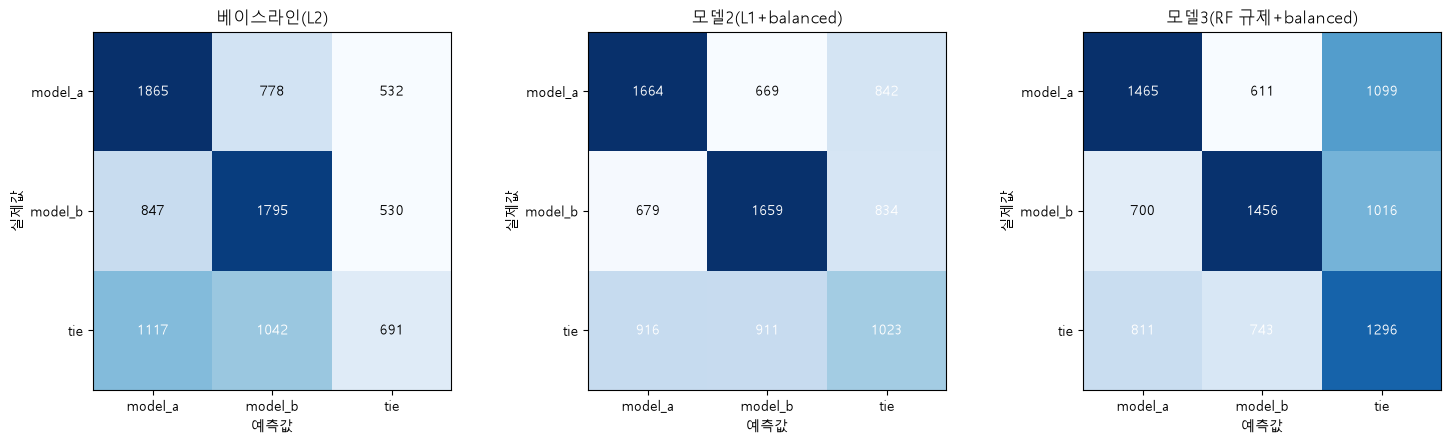

In [108]:
import matplotlib.pyplot as plt

# 3개 모델의 confusion matrix 시각화
class_labels = ['model_a', 'model_b', 'tie']

cms = {
    # 베이스라인의 예측값 변수명이 y_val_pred가 아니라면 맞춰서 수정하기
    "베이스라인(L2)": confusion_matrix(y_val, y_val_pred, labels=class_labels),
    "모델2(L1+balanced)": confusion_matrix(y_val, y_val_pred2, labels=class_labels),
    "모델3(RF 규제+balanced)": confusion_matrix(y_val, y_val_pred3, labels=class_labels),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, cm) in zip(axes, cms.items()):
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    ax.set_xlabel("예측값")
    ax.set_ylabel("실제값")
    thresh = cm.max() / 2
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig("confusion_matrices_comparison.png", dpi=150)
plt.show()

=== 원본 값 ===
                       베이스라인 |계수| 평균  모델2 |계수| 평균  모델3 RF importance
num__turn_count             0.015842     0.012265           0.007024
num__length_diff            0.126546     0.123754           0.246591
num__length_ratio           0.044331     0.043796           0.198178
num__abs_length_diff        0.101534     0.077285           0.126468
num__abs_length_ratio       0.009694     0.007350           0.069565

=== 정규화 값 (열 합=1, 모델 간 상대 비교용) ===
                       베이스라인 |계수| 평균  모델2 |계수| 평균  모델3 RF importance
num__turn_count             0.053171     0.046380           0.010842
num__length_diff            0.424728     0.467966           0.380644
num__length_ratio           0.148788     0.165611           0.305913
num__abs_length_diff        0.340779     0.292248           0.195219
num__abs_length_ratio       0.032535     0.027795           0.107382


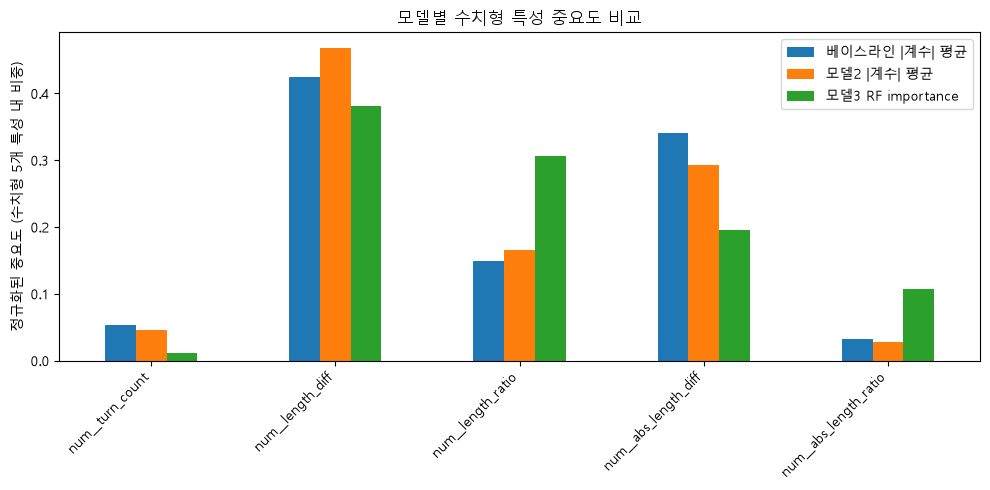

In [109]:
import numpy as np

# 수치형 5개 특성만 비교 
# - 로지스틱 계수: 클래스별 절댓값의 평균 → 방향과 무관한 영향력 크기로 환산
# - RandomForest: feature_importances_를 그대로 사용
numeric_cols = [f"num__{col}" for col in numeric_features]

feature_names = baseline_model.named_steps["preprocessor"].get_feature_names_out()
baseline_importance = pd.Series(
    np.abs(baseline_model.named_steps["classifier"].coef_).mean(axis=0), index=feature_names
)

feature_names2 = model2.named_steps["preprocessor"].get_feature_names_out()
model2_importance = pd.Series(
    np.abs(model2.named_steps["classifier"].coef_).mean(axis=0), index=feature_names2
)

feature_names3 = model3.named_steps["preprocessor"].get_feature_names_out()
model3_importance = pd.Series(
    model3.named_steps["classifier"].feature_importances_, index=feature_names3
)

importance_compare = pd.DataFrame({
    "베이스라인 |계수| 평균": baseline_importance[numeric_cols],
    "모델2 |계수| 평균": model2_importance[numeric_cols],
    "모델3 RF importance": model3_importance[numeric_cols],
})

# 모델 간 직접 비교를 위해 각 열을 합=1로 정규화 (같은 모델 내 상대적 중요도 비교용)
importance_normalized = importance_compare / importance_compare.sum()

print("=== 원본 값 ===")
print(importance_compare)
print("\n=== 정규화 값 (열 합=1, 모델 간 상대 비교용) ===")
print(importance_normalized)

# 막대그래프로 시각화
importance_normalized.plot(kind="bar", figsize=(10, 5))
plt.ylabel("정규화된 중요도 (수치형 5개 특성 내 비중)")
plt.title("모델별 수치형 특성 중요도 비교")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance_comparison.png", dpi=150)
plt.show()

In [110]:
from sklearn.metrics import classification_report, roc_auc_score

# Precision, ROC-AUC 계산 
models_info = {
    "베이스라인(L2)": (baseline_model, y_val_pred, y_val_proba),
    "모델2(L1+balanced)": (model2, y_val_pred2, y_val_proba2),
    "모델3(RF 규제+balanced)": (model3, y_val_pred3, y_val_proba3),
}

for name, (m, pred, proba) in models_info.items():
    print(f"\n{'='*50}\n{name}")
    print(classification_report(y_val, pred, labels=m.classes_, digits=4))
    # 다중 클래스 ROC-AUC: 각 클래스를 이 클래스 vs 나머지로 놓고 구한 뒤 평균
    auc = roc_auc_score(y_val, proba, labels=m.classes_, multi_class="ovr", average="macro")
    print(f"ROC-AUC (OvR, macro): {auc:.4f}")


베이스라인(L2)
              precision    recall  f1-score   support

     model_a     0.4871    0.5874    0.5326      3175
     model_b     0.4965    0.5659    0.5290      3172
         tie     0.3942    0.2425    0.3002      2850

    accuracy                         0.4731      9197
   macro avg     0.4593    0.4652    0.4539      9197
weighted avg     0.4616    0.4731    0.4593      9197

ROC-AUC (OvR, macro): 0.6553

모델2(L1+balanced)
              precision    recall  f1-score   support

     model_a     0.5106    0.5241    0.5173      3175
     model_b     0.5122    0.5230    0.5175      3172
         tie     0.3790    0.3589    0.3687      2850

    accuracy                         0.4725      9197
   macro avg     0.4673    0.4687    0.4678      9197
weighted avg     0.4704    0.4725    0.4713      9197

ROC-AUC (OvR, macro): 0.6552

모델3(RF 규제+balanced)
              precision    recall  f1-score   support

     model_a     0.4923    0.4614    0.4763      3175
     model_b     0.51

### ROC-AUC 결과 해석
베이스라인(0.6553)과 모델2(0.6552)의 ROC-AUC가 거의 동일함!
ROC-AUC는 분류 threshold와 무관하게 모델의 순위 매기기(랭킹) 능력만을 측정하는
지표다. class_weight="balanced"는 학습 과정에서 계수 자체를 다르게 만들지만,
결과적으로 나온 확률의 랭킹 능력은 베이스라인과 거의 같다는 것을 알 수 있다.
즉 recall/precision의 변화는 클래스 간 우선순위를 어떻게 재조정했는지에서
온 것이지, 데이터를 구별하는 근본적인 능력 자체가 달라진 게 아니다.

하지만 모델3의 ROC-AUC(0.6362)는 뚜렷하게 낮음... 다른 두 모델과 다르게
구별 능력 자체가 떨어짐.

In [111]:
import numpy as np

# 오류 분석: 실제 정답을 맞춘 확률이 가장 낮았던 행 10개
val_check = val_df.reset_index(drop=True).copy()
y_val_check = y_val.reset_index(drop=True)

true_idx = [list(model2.classes_).index(label) for label in y_val_check]
true_proba = y_val_proba2[np.arange(len(y_val_check)), true_idx]
val_check["true_class_proba"] = true_proba

worst = val_check.sort_values("true_class_proba").head(10)
print(worst[["winner", "length_diff", "length_ratio", "abs_length_diff",
             "abs_length_ratio", "turn_count", "true_class_proba"]])

       winner  length_diff  length_ratio  abs_length_diff  abs_length_ratio  \
6832  model_b        221.0      1.690096            221.0          1.690096   
616   model_b         67.0      0.130663             67.0          0.130663   
4210  model_b        928.0      0.506270            928.0          0.506270   
5196  model_a        233.0      0.840007            233.0          0.840007   
4904  model_a        354.0      0.343729            354.0          0.343729   
5021  model_b       1072.0      0.579936           1072.0          0.579936   
719   model_a       -175.0     -0.563935            175.0          0.563935   
2760  model_b       1909.0      0.852824           1909.0          0.852824   
2212  model_b         35.0      0.274076             35.0          0.274076   
3233  model_a          7.0      0.081917              7.0          0.081917   

      turn_count  true_class_proba  
6832           1          0.024150  
616            5          0.030378  
4210           1   

### 오류 분석 결과
가장 틀린 10개 행의 공통점: 실제 정답이 tie인 행이 하나도 없다. 

tie는 val_df의 31%를 차지하는데도
최악의 오답에 등장하지 않는다는 것은

-> (1) 모델이 크게 확신을 갖고 틀리는
경우: 실제로는 model_a/b가 이겼는데 tie로 착각한 경우
   (2) 반대로 실제 tie를 model_a/b로 강하게 확신해 틀리는 경우는 상대적으로 드물다.

### 평가 지표가 이 문제에서 의미하는 것

- **Log Loss**: 모델이 예측한 확률이 실제 정답과 얼마나 잘 맞는지, 틀렸을 때
  확신이 강할수록 더 큰 벌점을 주는 지표.(이 프로젝트의 공식 평가지표)
- **Accuracy**: 전체 예측 중 맞춘 비율. tie가 model_a/model_b보다 적은
  불균형 데이터라, Accuracy만 보면 model_a/model_b를 잘 맞히는 모델이
  실제보다 좋아 보일 수 있음.
- **Precision (클래스별)**: 예를 들어 tie의 Precision은 "모델이 tie라고
  예측한 것들 중 실제로 tie였던 비율"...모델이 tie라고 말했을 때 얼마나
  믿을 수 있는지.
- **Recall (클래스별)**: tie의 Recall은 "실제로 tie인 것들 중 모델이
  tie라고 맞힌 비율".
- **F1-score**: Precision과 Recall의 조화평균. 하나만 높고 다른 하나가
  낮은 경우를 걸러내는 균형 지표. (macro 평균은 클래스 크기와 무관하게
  세 클래스를 동등하게 취급함)
- **ROC-AUC (OvR)**: 각 클래스를 이 클래스 vs 나머지 전체로 놓고,
  모델이 실제 그 클래스인 행에 그렇지 않은 행보다 더 높은 확률을
  부여하는 정도를 측정하는 방식 (0.5=무작위 수준, 1.0=완벽한 구분). 세 클래스의
  AUC를 평균 낸 값.

## TASK3 결과 정리: 모델 평가 및 비교 

### 특성 중요도 비교
| 특성 | 베이스라인 | 모델2 | 모델3(RF) |
|---|---|---|---|
| turn_count | 5.32% | 4.64% | 1.08% |
| length_diff | 42.47% | 46.80% | 38.06% |
| length_ratio | 14.88% | 16.56% | 30.59% |
| abs_length_diff | 34.08% | 29.22% | 19.52% |
| abs_length_ratio | 3.25% | 2.78% | 10.74% |

- turn_count는 세 모델(선형 계수, L1 sparsity, 트리 importance) 모두에서
  가장 낮은 비중을 차지. 2주차부터 이어진 "turn_count는 승패 예측에
  거의 기여하지 않는다"는 결론이 세 가지 서로 다른 방법으로 재확인되었다.

- 방향성 특성(length_diff, length_ratio)이 세 모델 모두에서 magnitude
  특성(abs_length_diff, abs_length_ratio)보다 높은 비중을 차지했다.
  RandomForest는 하나의 연속형 특성에 대해 여러 번의 임계값 분기를 통해
  절댓값과 유사한 패턴을 학습할 수 있기 때문에, abs 특성에 크게 의존하지
  않고도 tie 예측 성능(recall 45.47%)을 달성했을 가능성 존재!
  

### 최종 결론
- Log Loss(공식 지표) 기준: 베이스라인이 근소하게 우수 (1.0248 CV 평균)
- F1(macro), 클래스 균형 기준: 모델2가 가장 우수 (0.4674)
- 예측 안정성(fold 간 분산) 기준: 모델3이 가장 우수 (±0.0010)
- 최종 권장 모델: **모델2(L1 + class_weight="balanced")** —
  전체 성능 손실을 최소화하면서 tie recall(24.25%→35.89%)과
  F1(macro)을 동시에 개선했기 때문


-----------------------------------------

## Week4

## TASK 1: 하이퍼파라미터 튜닝 및 앙상블

3주차에서 선정한 최종 모델(모델2: L1 로지스틱 회귀 + class_weight="balanced")이 기준

1) 하이퍼파라미터 튜닝

2) 서로 다른 계열의 모델(모델2, 모델3)을 결합하는 앙상블

(train_sub/val_df , 교차 검증 기준으로만 비교함)

### 하이퍼파라미터 튜닝

튜닝 파라미터는 `C`와 `l1_ratio`. 

`C`: 규제 강도를 조절하는 값(너무 작으면 과소적합, 너무 크면 과잉적합 위험이 커짐)

`l1_ratio`: L1과 L2 규제를 섞는 비율( 1.0(L1) 값을 낮춰 L2 비중을 살짝 섞은 elastic net 조합이 더 나은지 확인)

GridSearchCV로 전수 탐색 / 평가 기준: Log Loss / 
교차 검증 방식: 5-fold

In [112]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# preprocessor2는 cell 34에서 만듦
model2_for_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", LogisticRegression(
        solver="saga",
        class_weight="balanced",
        max_iter=1000
    )),
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__l1_ratio": [0.5, 0.8, 1.0],
}

grid_search = GridSearchCV(
    model2_for_tuning,
    param_grid=param_grid,
    scoring="neg_log_loss",
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_sub, y_train_sub)

print("최적 파라미터:", grid_search.best_params_)
print("튜닝 전 CV Log Loss: 1.0260")  # 3주차 cross_val_score 평균값 
print("튜닝 후 CV Log Loss:", -grid_search.best_score_)

best_model2 = grid_search.best_estimator_

최적 파라미터: {'classifier__C': 1, 'classifier__l1_ratio': 1.0}
튜닝 전 CV Log Loss: 1.0260
튜닝 후 CV Log Loss: 1.0267545078965086


In [113]:
from sklearn.model_selection import cross_val_score

model2_default = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", LogisticRegression(
        solver="saga", l1_ratio=1.0, class_weight="balanced", max_iter=1000
    )),
])

before_scores = cross_val_score(
    model2_default, X_train_sub, y_train_sub, cv=5, scoring="neg_log_loss"
)
print("튜닝 전 CV Log Loss (X_train_sub 기준):", -before_scores.mean())
print("튜닝 후 CV Log Loss (X_train_sub 기준):", -grid_search.best_score_)

튜닝 전 CV Log Loss (X_train_sub 기준): 1.0267551785038218
튜닝 후 CV Log Loss (X_train_sub 기준): 1.0267545078965086


### 하이퍼파라미터 튜닝 결과

최적값 C=1, l1_ratio=1.0 기존 설정과 동일. 튜닝 전/후 CV Log Loss도 1.02675로 거의 일치.

=> 모델2는 이미 적절한 규제 강도 근처에 있으며 추가 개선될 가능성 낮음.

### 앙상블 기법 

(각 모델의 약점을 보완하기 위함)

1) VotingClassifier(soft voting): 두 모델이 예측한 클래스별 확률을 단순 평균 내는 방식. 

2) StackingClassifier: 두 모델의 예측 결과를 입력으로 받는 메타 모델을 별도로
학습 -> 상황에 따른 최적 조합 방식을 데이터로부터 학습. (과적합 위험)

In [114]:
from sklearn import set_config
set_config(display="text")
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[("model2", best_model2), ("model3", model3)],
    voting="soft"
)
voting_model.fit(X_train_sub, y_train_sub)

VotingClassifier(estimators=[('model2',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['turn_count',
                                                                                 'length_diff',
                                                                                 'length_ratio',
                                                                                 'abs_length_diff',
                                                                                 'abs_length_ratio']),
                                                                               ('cat',
                                                                                OneHotEncoder(handle_unknown='ignore'),
              

In [115]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

models = {
    "모델2 (튜닝 전)": model2,
    "모델2 (튜닝 후)": best_model2,
    "Voting": voting_model,
}

for name, m in models.items():
    proba = m.predict_proba(X_val)
    pred = m.predict(X_val)
    print(name,
          "LogLoss:", log_loss(y_val, proba, labels=m.classes_),
          "Acc:", accuracy_score(y_val, pred),
          "F1(macro):", f1_score(y_val, pred, average="macro"))

모델2 (튜닝 전) LogLoss: 1.0248267397372113 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
모델2 (튜닝 후) LogLoss: 1.0248268065888824 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
Voting LogLoss: 1.0294281198210633 Acc: 0.47069696640208764 F1(macro): 0.4692149346768235


두 모델의 성능 차이가 많이 남... 전체적으로 모델2의 성능 위주로 결과가 나오고 모델3은 조금만 반영됨.

In [116]:
from sklearn.ensemble import VotingClassifier

voting_model_weighted = VotingClassifier(
    estimators=[("model2", best_model2), ("model3", model3)],
    voting="soft",
    weights=[2, 1]  # 모델2에 2배
)
voting_model_weighted.fit(X_train_sub, y_train_sub)

VotingClassifier(estimators=[('model2',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['turn_count',
                                                                                 'length_diff',
                                                                                 'length_ratio',
                                                                                 'abs_length_diff',
                                                                                 'abs_length_ratio']),
                                                                               ('cat',
                                                                                OneHotEncoder(handle_unknown='ignore'),
              

In [117]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

models = {
    "모델2 (튜닝 전)": model2,
    "Voting (1:1)": voting_model,
    "Voting (2:1)": voting_model_weighted,
}

for name, m in models.items():
    proba = m.predict_proba(X_val)
    pred = m.predict(X_val)
    print(name,
          "LogLoss:", log_loss(y_val, proba, labels=m.classes_),
          "Acc:", accuracy_score(y_val, pred),
          "F1(macro):", f1_score(y_val, pred, average="macro"))

모델2 (튜닝 전) LogLoss: 1.0248267397372113 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
Voting (1:1) LogLoss: 1.0294281198210633 Acc: 0.47069696640208764 F1(macro): 0.4692149346768235
Voting (2:1) LogLoss: 1.0259056099717871 Acc: 0.4724366641296075 F1(macro): 0.46961493063069254


In [118]:
from sklearn.ensemble import VotingClassifier

voting_model_weighted3 = VotingClassifier(
    estimators=[("model2", best_model2), ("model3", model3)],
    voting="soft",
    weights=[3, 1]
)
voting_model_weighted3.fit(X_train_sub, y_train_sub)

VotingClassifier(estimators=[('model2',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['turn_count',
                                                                                 'length_diff',
                                                                                 'length_ratio',
                                                                                 'abs_length_diff',
                                                                                 'abs_length_ratio']),
                                                                               ('cat',
                                                                                OneHotEncoder(handle_unknown='ignore'),
              

In [119]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

models = {
    "모델2 (튜닝 전)": model2,
    "Voting (1:1)": voting_model,
    "Voting (2:1)": voting_model_weighted,  
    "Voting (3:1)": voting_model_weighted3,  
}

for name, m in models.items():
    proba = m.predict_proba(X_val)
    pred = m.predict(X_val)
    print(name,
          "LogLoss:", log_loss(y_val, proba, labels=m.classes_),
          "Acc:", accuracy_score(y_val, pred),
          "F1(macro):", f1_score(y_val, pred, average="macro"))

모델2 (튜닝 전) LogLoss: 1.0248267397372113 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
Voting (1:1) LogLoss: 1.0294281198210633 Acc: 0.47069696640208764 F1(macro): 0.4692149346768235
Voting (2:1) LogLoss: 1.0259056099717871 Acc: 0.4724366641296075 F1(macro): 0.46961493063069254
Voting (3:1) LogLoss: 1.0248249137049603 Acc: 0.4729803196694574 F1(macro): 0.46935002300835693


미세한 개선 신호는 있었지만, 유의미한 결과라고 보기는 어려움.

In [120]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_model = StackingClassifier(
    estimators=[("model2", best_model2), ("model3", model3)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_model.fit(X_train_sub, y_train_sub)

StackingClassifier(cv=5,
                   estimators=[('model2',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  StandardScaler(),
                                                                                  ['turn_count',
                                                                                   'length_diff',
                                                                                   'length_ratio',
                                                                                   'abs_length_diff',
                                                                                   'abs_length_ratio']),
                                                                                 ('cat',
                                                                                  OneHotE

In [121]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

models = {
    "모델2 (단독)": model2,
    "Voting (3:1)": voting_model_weighted3,
    "Stacking": stacking_model,
}

for name, m in models.items():
    proba = m.predict_proba(X_val)
    pred = m.predict(X_val)
    print(name,
          "LogLoss:", log_loss(y_val, proba, labels=m.classes_),
          "Acc:", accuracy_score(y_val, pred),
          "F1(macro):", f1_score(y_val, pred, average="macro"))

모델2 (단독) LogLoss: 1.0248267397372113 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
Voting (3:1) LogLoss: 1.0248249137049603 Acc: 0.4729803196694574 F1(macro): 0.46935002300835693
Stacking LogLoss: 1.0215736497468384 Acc: 0.4834185060345765 F1(macro): 0.4724483116219467


개선됨.

(추가)

1) Stacking + passthrough

2) 모델3 확률 보정(Calibration)

In [122]:
# Stacking + passthrough

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_model_v2 = StackingClassifier(
    estimators=[("model2", best_model2), ("model3", model3)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    passthrough=True
)
stacking_model_v2.fit(X_train_sub, y_train_sub)

ValueError: could not convert string to float: 'guanaco-33b'

전처리는 각 파이프라인 내부에만 있고 X는 그대로 원본이라, 전처리기가 없는 메타 모델에 원본 범주형 데이터가
그대로 전달되어 오류가 발생함... 시간 관계상 보류

In [123]:
from sklearn.calibration import CalibratedClassifierCV

model3_calibrated = CalibratedClassifierCV(model3, method="isotonic", cv=5)
model3_calibrated.fit(X_train_sub, y_train_sub)

# 보정된 모델3으로 Stacking도 다시 만들어서 비교
stacking_model_calibrated = StackingClassifier(
    estimators=[("model2", best_model2), ("model3", model3_calibrated)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)
stacking_model_calibrated.fit(X_train_sub, y_train_sub)

StackingClassifier(cv=5,
                   estimators=[('model2',
                                Pipeline(steps=[('preprocessor',
                                                 ColumnTransformer(transformers=[('num',
                                                                                  StandardScaler(),
                                                                                  ['turn_count',
                                                                                   'length_diff',
                                                                                   'length_ratio',
                                                                                   'abs_length_diff',
                                                                                   'abs_length_ratio']),
                                                                                 ('cat',
                                                                                  OneHotE

In [124]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

models = {
    "모델2 (단독)": model2,
    "Voting (3:1)": voting_model_weighted3,
    "Stacking (기존)": stacking_model,
    "모델3 (보정 전)": model3,
    "모델3 (보정 후)": model3_calibrated,
    "Stacking (보정된 모델3)": stacking_model_calibrated,
}

for name, m in models.items():
    proba = m.predict_proba(X_val)
    pred = m.predict(X_val)
    print(name,
          "LogLoss:", log_loss(y_val, proba, labels=m.classes_),
          "Acc:", accuracy_score(y_val, pred),
          "F1(macro):", f1_score(y_val, pred, average="macro"))

모델2 (단독) LogLoss: 1.0248267397372113 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
Voting (3:1) LogLoss: 1.0248249137049603 Acc: 0.4729803196694574 F1(macro): 0.46935002300835693
Stacking (기존) LogLoss: 1.0215736497468384 Acc: 0.4834185060345765 F1(macro): 0.4724483116219467
모델3 (보정 전) LogLoss: 1.0501214108770676 Acc: 0.4585190823094487 F1(macro): 0.4590434664540621
모델3 (보정 후) LogLoss: 1.0397549569446238 Acc: 0.45460476242252906 F1(macro): 0.43865793723538055
Stacking (보정된 모델3) LogLoss: 1.0209804001808807 Acc: 0.48494074154615635 F1(macro): 0.4700076408422389


모델2 튜닝(개선x) -> 모델2+모델3 Voting(1:1 >> 2:1 >> 3:1, 미세 개선O) -> 모델2+모델3 Stacking(가장 큰 개선, Log Loss 1.0248 >> 1.0216) -> 모델3 보정 후 재조합(기존 Stacking과 유사)

최종 모델 :기존 Stacking(보정x)

## TASK 2: 차원 축소

전처리, 인코딩 후 특성 수가 133개(수치형 5개 + model_a/model_b 원-핫 인코딩
128개)


1. 특성 수 30개 이상 -> 해당 (133개) -> 확인

2. 상관계수 0.8 이상 -> 0.8 이상인 변수쌍 여부 확인

3. 이미지/텍스트 임베딩 -> 해당 안 됨(임베딩 안 씀) -> 불필요

4. 비지도 문제 -> 해당 안 됨(target = winner) -> 군집 불필요

5. 세그먼트 도출 목적 -> 해당 안 됨(승패 예측이 목적. 군집 분류x) -> 군집 불필요

### 상관계수 확인

수치형 5개 특성 간 상관계수 확인

군집을 적용하지 않는 이유 + PCA 적용 전 다중공선성 여부를 함께 확인하기 위함. 

In [125]:
print(train_sub[numeric_features].corr())

                  turn_count  length_diff  length_ratio  abs_length_diff  \
turn_count          1.000000     0.000728      0.001452         0.027455   
length_diff         0.000728     1.000000      0.723314        -0.017221   
length_ratio        0.001452     0.723314      1.000000        -0.017754   
abs_length_diff     0.027455    -0.017221     -0.017754         1.000000   
abs_length_ratio   -0.101500    -0.021441     -0.033446         0.479647   

                  abs_length_ratio  
turn_count               -0.101500  
length_diff              -0.021441  
length_ratio             -0.033446  
abs_length_diff           0.479647  
abs_length_ratio          1.000000  


### 상관계수 확인 결과

수치형 5개 특성 간 상관계수: length_diff와 length_ratio가
0.723으로 가장 높음 / 기준인 r의 절댓값이 0.8은 넘지 않음 -> PCA/변수
선택이 필수x

나머지 특성 쌍은 대부분 상관계수 0.1 이하로
낮음 / 하지만 특성 수(133개) 조건으로 PCA가 필수임!

In [126]:
import time

start = time.time()
model2.fit(X_train_sub, y_train_sub)
time_before = time.time() - start

print(f"PCA 적용 전 특성 수: 133, 학습 시간: {time_before:.3f}초")

c:\Users\gjymo\OneDrive\바탕 화면\pilot_LLM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gjymo\OneDrive\바탕 화면\pilot_LLM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


PCA 적용 전 특성 수: 133, 학습 시간: 11.056초


In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import time

# PCA용 전처리기: OneHotEncoder를 dense 출력으로 설정 (sparse_output=False)
preprocessor2_dense = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

model2_pca = Pipeline(steps=[
    ("preprocessor", preprocessor2_dense),
    ("pca", PCA(n_components=0.95, random_state=42)),
    ("classifier", LogisticRegression(
        solver="saga", l1_ratio=1.0, class_weight="balanced", max_iter=1000
    )),
])

start = time.time()
model2_pca.fit(X_train_sub, y_train_sub)
time_after = time.time() - start

proba_after = model2_pca.predict_proba(X_val)
pred_after = model2_pca.predict(X_val)

n_components_used = model2_pca.named_steps["pca"].n_components_
print(f"PCA 적용 후 특성 수: {n_components_used}, 학습 시간: {time_after:.3f}초")

PCA 적용 후 특성 수: 72, 학습 시간: 14.331초


In [128]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

print("PCA 적용 전 — LogLoss:", log_loss(y_val, proba_before, labels=model2.classes_),
      "Acc:", accuracy_score(y_val, pred_before),
      "F1(macro):", f1_score(y_val, pred_before, average="macro"))

print("PCA 적용 후 — LogLoss:", log_loss(y_val, proba_after, labels=model2_pca.classes_),
      "Acc:", accuracy_score(y_val, pred_after),
      "F1(macro):", f1_score(y_val, pred_after, average="macro"))

PCA 적용 전 — LogLoss: 1.0248265865217234 Acc: 0.4725453952375775 F1(macro): 0.4678383821543903
PCA 적용 후 — LogLoss: 1.0390215857906528 Acc: 0.4600413178210286 F1(macro): 0.4566243974197846


### PCA 적용 결과

[PCA 적용]

학습 시간: 10.620초 -> 13.182초 

Log Loss: 1.0248 -> 1.0390

Accuracy: 47.25% -> 46.00% 

F1(macro): 0.4678 -> 0.4566


=> 전체적으로 성능이 나빠짐. 

모델2가 L1 규제로 이미 클래스 구분에 유용한 특성만
남기는 지도 방식의 선택을 한 상태이다. 하지만, PCA는 타깃과 무관하게 분산이
큰 방향만 찾는 비지도 방식이라 원-핫 인코딩된 개별 모델 정보(특정
모델이 강하다/약하다)가 여러 성분에 걸쳐 흐려졌기 때문으로 예상..


학습 시간이 늘어난 이유: PCA의 SVD 분해 자체에 드는 계산 비용이, 특성
수 감소로 절약되는 분류기 학습 시간보다 컸기 때문. 

=> 최종 모델에는 PCA를 적용x, 원본 133개 특성을 그대로 사용.

## 4주차 TASK 3: 최종 테스트 세트 평가

In [ ]:
# test_df에 train_df와 동일한 방식으로 파생 변수를 생성

import numpy as np

# 1. 응답 길이 / 턴 수 (train_df와 동일한 함수 사용)
test_df["response_a_len"] = test_df["response_a"].apply(get_total_length)
test_df["response_b_len"] = test_df["response_b"].apply(get_total_length)
test_df["turn_count"] = test_df["prompt"].apply(get_turn_count)

# 2. 이상치 클리핑: train_df에서 계산해둔 a_upper, b_upper 그대로 적용 (재계산 x..(데이터 누수 방지))
test_df["response_a_len"] = test_df["response_a_len"].clip(upper=a_upper)
test_df["response_b_len"] = test_df["response_b_len"].clip(upper=b_upper)

# 3. length_diff / length_ratio (train_df와 동일한 로그 비율 방식)
test_df["length_diff"] = test_df["response_a_len"] - test_df["response_b_len"]
test_df["length_ratio"] = np.log(test_df["response_a_len"] + 1) - np.log(test_df["response_b_len"] + 1)

# 4. abs 특성
test_df["abs_length_diff"] = test_df["length_diff"].abs()
test_df["abs_length_ratio"] = test_df["length_ratio"].abs()

print(test_df[numeric_features].describe())

         turn_count   length_diff  length_ratio  abs_length_diff  \
count  11496.000000  11496.000000  11496.000000     11496.000000   
mean       1.237996     -9.743259      0.000929       554.036491   
std        0.859957    795.694789      1.050085       571.175980   
min        1.000000  -3926.000000     -5.754159         0.000000   
25%        1.000000   -390.000000     -0.455238       124.750000   
50%        1.000000     -3.500000     -0.000887       377.000000   
75%        1.000000    366.250000      0.442220       804.250000   
max       17.000000   3944.500000      8.280331      3944.500000   

       abs_length_ratio  
count      11496.000000  
mean           0.701292  
std            0.781553  
min            0.000000  
25%            0.177199  
50%            0.447296  
75%            0.934335  
max            8.280331  


In [130]:
from sklearn.metrics import log_loss, accuracy_score, f1_score, classification_report

X_test = test_df[numeric_features + categorical_features]
y_test = test_df["winner"]

test_proba = stacking_model.predict_proba(X_test)
test_pred = stacking_model.predict(X_test)

test_logloss = log_loss(y_test, test_proba, labels=stacking_model.classes_)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")

print(f"Test Log Loss: {test_logloss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1(macro): {test_f1:.4f}")

print("\n--- classification_report ---")
print(classification_report(y_test, test_pred))

Test Log Loss: 1.0121
Test Accuracy: 0.4934
Test F1(macro): 0.4814

--- classification_report ---
              precision    recall  f1-score   support

     model_a       0.51      0.58      0.54      4030
     model_b       0.52      0.56      0.54      3929
         tie       0.42      0.31      0.36      3537

    accuracy                           0.49     11496
   macro avg       0.48      0.49      0.48     11496
weighted avg       0.49      0.49      0.49     11496



In [131]:
from sklearn.metrics import log_loss, accuracy_score, f1_score

test_models = {
    "베이스라인": baseline_model,
    "모델2": model2,
    "모델3": model3,
    "Stacking (최종)": stacking_model,
}

for name, m in test_models.items():
    proba = m.predict_proba(X_test)
    pred = m.predict(X_test)
    print(name,
          "LogLoss:", log_loss(y_test, proba, labels=m.classes_),
          "Acc:", accuracy_score(y_test, pred),
          "F1(macro):", f1_score(y_test, pred, average="macro"))

베이스라인 LogLoss: 1.0162659893228911 Acc: 0.4909533750869868 F1(macro): 0.4722912369717453
모델2 LogLoss: 1.017865687549939 Acc: 0.4889526791927627 F1(macro): 0.4845518807378535
모델3 LogLoss: 1.0441957532308639 Acc: 0.4659881697981907 F1(macro): 0.4662435337820148
Stacking (최종) LogLoss: 1.012071288892263 Acc: 0.4933890048712596 F1(macro): 0.4814323581950249


In [132]:
from sklearn.metrics import classification_report

print(classification_report(y_test, model2.predict(X_test)))

              precision    recall  f1-score   support

     model_a       0.53      0.53      0.53      4030
     model_b       0.52      0.53      0.53      3929
         tie       0.41      0.39      0.40      3537

    accuracy                           0.49     11496
   macro avg       0.48      0.49      0.48     11496
weighted avg       0.49      0.49      0.49     11496



결론:

최종 모델은 test에서 Log Loss 1.0121로, 기존 CV 평균보다 낮게 나왔고 다른 세 모델도
함께 확인해본 결과 네 모델 모두 test 성능이 CV 평균보다 좋게 나왔다.

=> Stacking만의 현상보다는 이 test 분할 자체가 쉬운
조합이었기 때문으로 해석 가능..

한계점: 

모델2 단독과 비교하면 Log Loss, Accuracy는 더 우수했지만, tie recall은 낮아졌다.
(Stacking이 전체 정확도는 개선했지만, tie에서는 모델2보다 판단하지 못하는 trade-off)
